# Проект "Прогнозирование удовлетворённости и оттока сотрудников"

Мы — команда HR-аналитиков компании «Работа с заботой». Наша цель — помочь бизнесу принимать обоснованные кадровые решения на основе данных. В своей работе мы используем современные аналитические подходы и методы машинного обучения, чтобы выявлять риски, повышать вовлечённость сотрудников и минимизировать затраты, связанные с текучестью персонала.

В этом проекте мы получили от заказчика данные о сотрудниках компании и решим две ключевые задачи:

- Построим модель, способную предсказывать уровень удовлетворённости сотрудника на основе характеристик рабочего процесса и истории взаимодействия с компанией.

- Разработаем модель, прогнозирующую, уволится ли сотрудник в ближайшее время.

Уровень удовлетворённости сотрудников — критически важный показатель. Его обычно получают из опросов, которые требуют ресурсов на проведение. Мы стремились автоматизировать этот процесс и сделать его масштабируемым — за счёт предиктивной модели, которая позволяет оценить удовлетворённость без дополнительных затрат времени и усилий.

Прогнозирование увольнений — ещё одна приоритетная задача HR-аналитики. Внезапный уход сотрудников, особенно ценных, может нанести компании значительный ущерб. Наша модель призвана минимизировать подобные риски за счёт раннего выявления потенциальных кандидатов на уход.

В дальнейшем результаты модели можно интегрировать в HR-процессы и использовать для персонализированных действий по удержанию сотрудников, корректировки условий труда или внутреннего перемещения.

# Этапы решения задач
1. Модель для предсказания уровня удовлетворённости сотрудника
   - Загрузка и изучение данных;
   - Предобработка данных;
   - Исследовательский анализ данных;
   - Построение пайплайна;
   - Обучение моделей;
   - Оценка качества
2. Модель, прогнозирующая вероятность увольнения сотрудника в ближайшее время
    - Объединение данных;
    - Исследовательский анализ;
    - Построение пайплайна и обучение;
    - Оценка по ROC-AUC

# Загрузка и изучение данных

In [1]:
!pip install phik

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import OneHotEncoder 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    confusion_matrix, 
    classification_report, 
    r2_score, 
    make_scorer,
    mean_absolute_error, 
    mean_squared_error,
    roc_auc_score
)
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import matplotlib
import phik, shap
import matplotlib.ticker as mtick
from scipy import stats
from sklearn.model_selection import cross_val_score
from scipy.stats import gaussian_kde
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyRegressor
from phik.report import plot_correlation_matrix


Константы:

In [3]:
RANDOM_STATE=42

Выполним загрузку файлов:

In [4]:
try:
# Файлы для 1-й задачи
    
    df_test_features = pd.read_csv('/datasets/test_features.csv', sep=',')
    df_train_features = pd.read_csv('/datasets/train_job_satisfaction_rate_fixed.csv', sep=',')
    df_target = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv', sep=',')
    
# Файлы для 2-й задачи
    
    df_train_quit = pd.read_csv('/datasets/train_quit.csv', sep=',')
    df_test_target_quit = pd.read_csv('/datasets/test_target_quit.csv', sep=',')
    
except FileNotFoundError:
# Файлы для 1-й задачи
    
    df_train_features = pd.read_csv('train_job_satisfaction_rate_fixed.csv', sep=',')
    df_target = pd.read_csv('test_target_job_satisfaction_rate.csv', sep=',')
    df_test_features = pd.read_csv('test_features.csv', sep=',')
    
# Файлы для 2-й задачи
    df_train_quit = pd.read_csv('train_quit.csv', sep=',')
    df_test_target_quit = pd.read_csv('test_target_quit.csv', sep=',')


Функция для знакомства с файлами:

In [5]:
def get_dataset_info(df, name="Dataset", sample_rows=5):
    """
    Параметры:
    - df (pd.DataFrame): Датасет для анализа.
    - name (str): Название датасета (для заголовка).
    - sample_rows (int): Количество строк для вывода (head).
    Возвращает:
    - dict: Словарь с основной информацией о датасете.
    """
    info = {
        "name": name,
        "head": df.head(sample_rows),
        "shape": df.shape,
    }

    # Вывод информации в консоль
    print("\nОбщая информация:")
    display(df.info())
    
    
    print("\nРазмер датасета (строки, столбцы):")
    display(f"{info['shape']} (rows, cols)")


    print("\nПервые строки данных:")
    display(info["head"])

**Данные тренировочной выборки:**

In [6]:
get_dataset_info(df_train_features) # тренировочная выборка


Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


None


Размер датасета (строки, столбцы):


'(4000, 10) (rows, cols)'


Первые строки данных:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


Видимых проблем с данными нет.

**Данные тестовой выборки:**

In [7]:
get_dataset_info(df_test_features)


Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


None


Размер датасета (строки, столбцы):


'(2000, 9) (rows, cols)'


Первые строки данных:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


Видим, что тестовая выборка по размеру в 2 раза меньше (2000 против 4000 строк), чем тренировочная. Из неё уже удалён целевой признак - уровень удовлетворённости.

**Целевой признак тестовой выборки:**

In [8]:
get_dataset_info(df_target)


Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


None


Размер датасета (строки, столбцы):


'(2000, 2) (rows, cols)'


Первые строки данных:


,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


### Вывод
На этом этапе проблем с данными не обнаружено.

# Предобработка данных
- выполним проверку наличия явных и неявных дубликатов;
- выполним проверку наличия пропусков. Если они есть, то обработаем их позже в пайплайне

Создадим функцию для проверки уникальных значений в столбцах типа `object` в датафрейме:

In [9]:
def get_unique_values(df):
    unique_values = []
    for i in df:
        if df[i].dtypes == "object":
            unique_values.append(df[i].unique())
    return unique_values

## Проверка наличия неявных дубликатов
Проведём проверку тестовой и тренировочной выборок:

In [10]:
print('Уникальные значения столбцов тренировочной выборки:\n')
display(get_unique_values(df_train_features))
print('\n')
print('Уникальные значения столбцов тестовой выборки:\n')
display(get_unique_values(df_test_features))

Уникальные значения столбцов тренировочной выборки:



[array(['sales', 'hr', 'technology', 'purchasing', 'marketing', nan],
       dtype=object),
 array(['junior', 'middle', 'senior', nan], dtype=object),
 array(['medium', 'high', 'low'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object)]



Уникальные значения столбцов тестовой выборки:



[array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan, ' '],
       dtype=object),
 array(['junior', 'middle', 'sinior', nan], dtype=object),
 array(['medium', 'low', 'high', ' '], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object)]

Видим пропущенные `nan` значения в обеих выборках, в тестовой присутствуют "пустые" строки `' '`, также в тестовой выборке есть опечатка (`sinior` вместо `senior`).

Исправим опечатку:

In [11]:
df_test_features['level'] = df_test_features['level'].replace({'sinior': 'senior'})

Проверим:

In [12]:
df_test_features['level'].unique()

array(['junior', 'middle', 'senior', nan], dtype=object)

Обработаем пустые строки, напишем функцию для замены их на `nan`

In [13]:
def clean_categorical(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    • Заменяет строку ' ' → np.nan  
    • Убирает лишние пробелы, приводит к нижнему регистру  
    """
    df = df.copy()
    for col in cols:
        df[col] = (
            df[col]
            .replace(' ', np.nan)        # строка из одного пробела → NaN
            .str.strip()                 # обрезаем крайние пробелы
            .str.lower()                 # единый регистр
        )
    return df

In [14]:
cat_cols = ['dept', 'level', 'workload',
            'last_year_promo', 'last_year_violations']
# убираем пробелы из тестовой выборки
df_test_features  = clean_categorical(df_test_features,  cat_cols)

In [15]:
print('Уникальные значения столбцов тестовой выборки:\n')
display(get_unique_values(df_test_features))

Уникальные значения столбцов тестовой выборки:



[array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan],
       dtype=object),
 array(['junior', 'middle', 'senior', nan], dtype=object),
 array(['medium', 'low', 'high', nan], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object)]

От пустых строк избавились, заполнив их `nan` значениями

## Проверка на явные дубликаты
Проведём проверку на явные дубликаты и воспользуемся функцией для подсчёта количества дубликатов и пропусков:

In [16]:
def check_duplicates_and_missing(df: pd.DataFrame):
    duplicate_count = df.duplicated().sum()
    print(f"Количество дубликатов: {duplicate_count}")
    
    missing_values = df.isna().sum()
    print(f"Количество пропусков: {missing_values.sum()}")
   

    if duplicate_count == 0 and missing_values.sum() == 0:
        print("\nДубликаты и пропуски отсутствуют.")

In [17]:
print('Проверка тренировочной выборки: \n')
check_duplicates_and_missing(df_train_features)
print('Проверка тестовой выборки: \n')
check_duplicates_and_missing(df_test_features)

Проверка тренировочной выборки: 

Количество дубликатов: 0
Количество пропусков: 10
Проверка тестовой выборки: 

Количество дубликатов: 0
Количество пропусков: 5


Проверим наличие дубликатов без учёта id:

In [18]:
print('Проверка тренировочной выборки без учёта id: \n')
check_duplicates_and_missing(df_train_features.drop(columns=['id']))
print('Проверка тестовой выборки без учёта id: \n')
check_duplicates_and_missing(df_test_features.drop(columns=['id']))

Проверка тренировочной выборки без учёта id: 

Количество дубликатов: 245
Количество пропусков: 10
Проверка тестовой выборки без учёта id: 

Количество дубликатов: 557
Количество пропусков: 5


Необходимо избавиться от дубликатов в тренировочной выборке:

In [19]:
features = df_train_features.columns.drop(['id'])  
df_train_features = df_train_features.drop_duplicates(subset=features)

Проверим наличие дубликатов:

In [20]:
print('Проверка тренировочной выборки без учёта id: \n')
check_duplicates_and_missing(df_train_features.drop(columns=['id']))

Проверка тренировочной выборки без учёта id: 

Количество дубликатов: 0
Количество пропусков: 10


##### Вывод
В тестовой выборке 5 пропуска, в тренировочной - 10. Обработаем пропуски в пайплайне.

## Вывод по предобработке данных
- исправили опечатки в значениях признака `level` в тестовой выборке;
- заменили пустые строки на значения `nan`, чтобы в дальнейшем заполнить их в пайплайне/

# Исследовательский анализ данных
1. Проведём статистический анализ данных:
   - оценим максимальное и минимальное значения всех количественных признаков;
   - оценим средние и медианные значения;
   - визуализируем зависимости.
2. Проведём корреляционный анализ.

Статистический анализ данных

Используем функцию для статистического анализа данных:

In [21]:
def stat_analytics(df):
    df_desc = df.drop(columns=['id'])
    display(df_desc.describe())
    print('\nВизуализация распределения количественных признаков')
    numeric_cols = df.select_dtypes(include=['number']).drop(columns=['id']).columns
    for col in numeric_cols:
            plt.figure(figsize=(10, 4))
    
            plt.subplot(1, 2, 1)
            sns.histplot(df[col], kde=True, bins=30)
            plt.title(f'Распределение {col}')
    
            plt.subplot(1, 2, 2)
            sns.boxplot(x=df[col])
            plt.title(f'Boxplot {col}')
    
            plt.tight_layout()
            plt.show()
        
    print('\nВизуализация распределения категориальных признаков')
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        plt.figure(figsize=(10, 5))
        sns.countplot(x=col, data=df, order=df[col].value_counts().index)
        plt.title(f'Распределение категорий в {col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,3755.000000,3755.000000,3755.000000,3755.000000
mean,3.817044,3.463648,34457.416778,0.532554
std,2.557142,1.026265,15050.643870,0.226393
min,1.000000,1.000000,12000.000000,0.030000
25%,2.000000,3.000000,22800.000000,0.350000
50%,3.000000,4.000000,31200.000000,0.550000
75%,6.000000,4.000000,44400.000000,0.710000
max,10.000000,5.000000,98400.000000,1.000000



Визуализация распределения количественных признаков


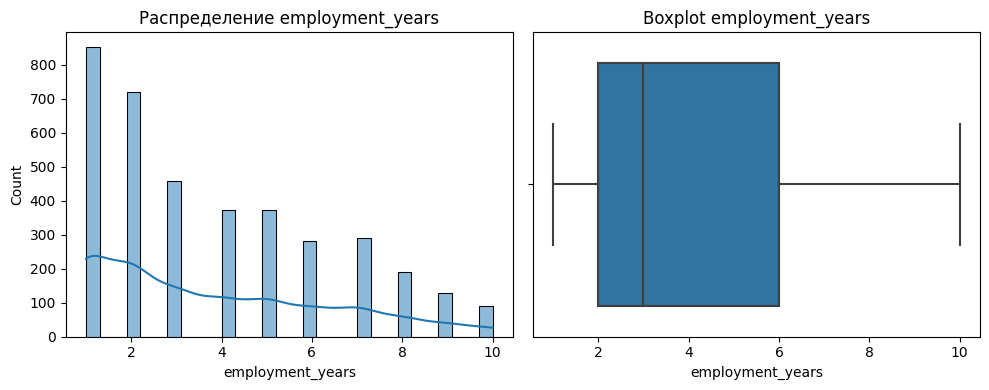

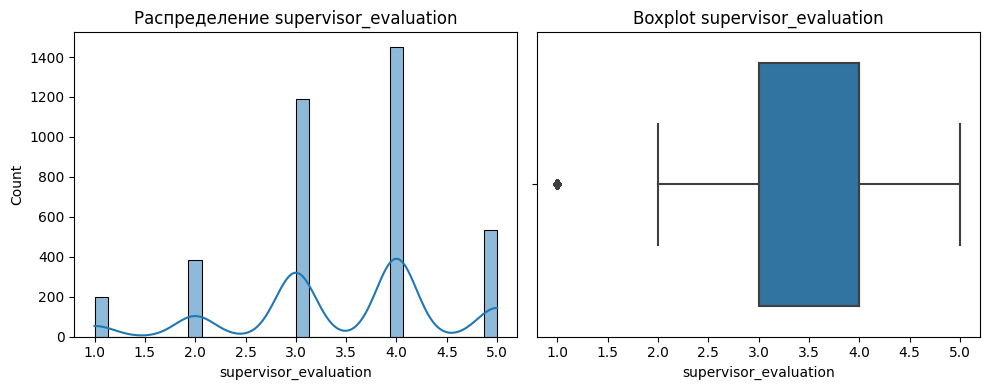

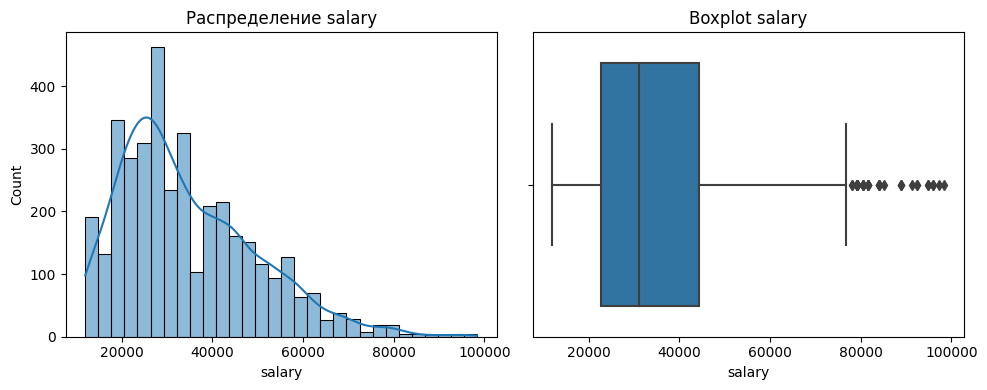

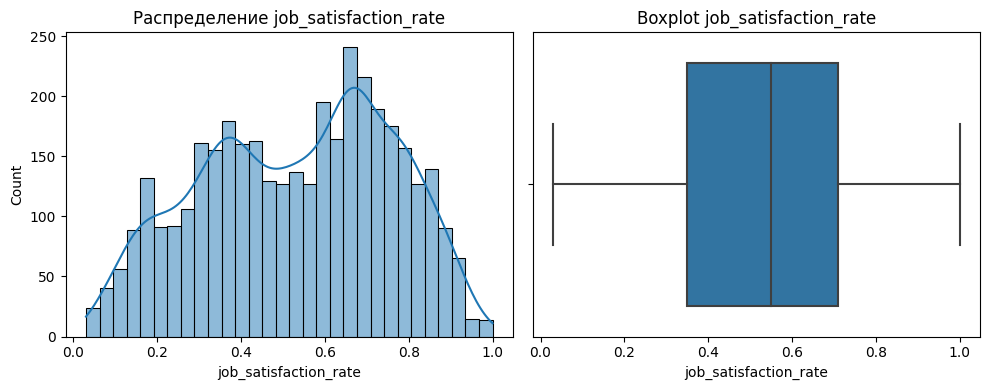


Визуализация распределения категориальных признаков


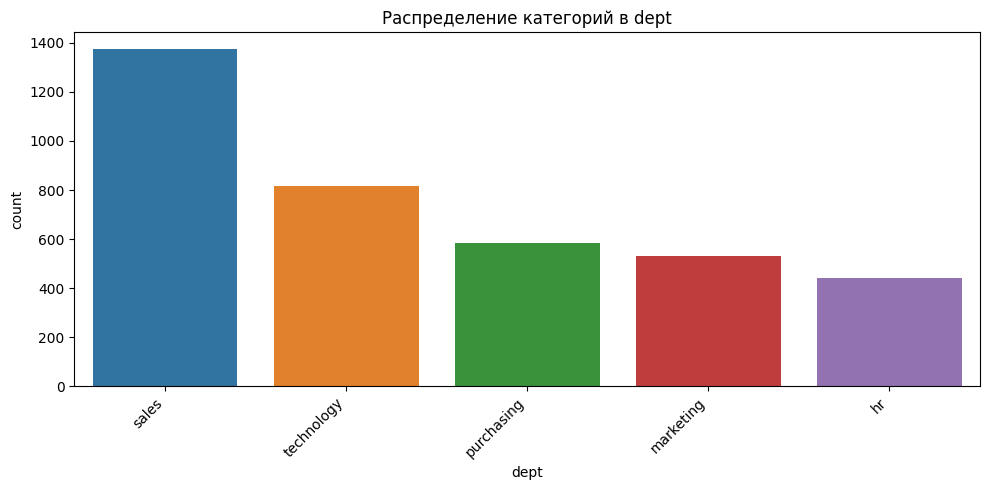

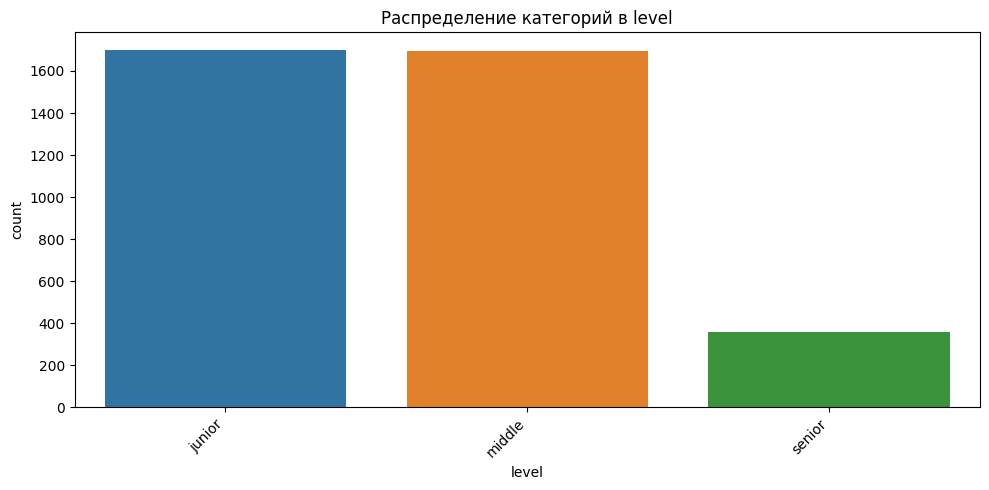

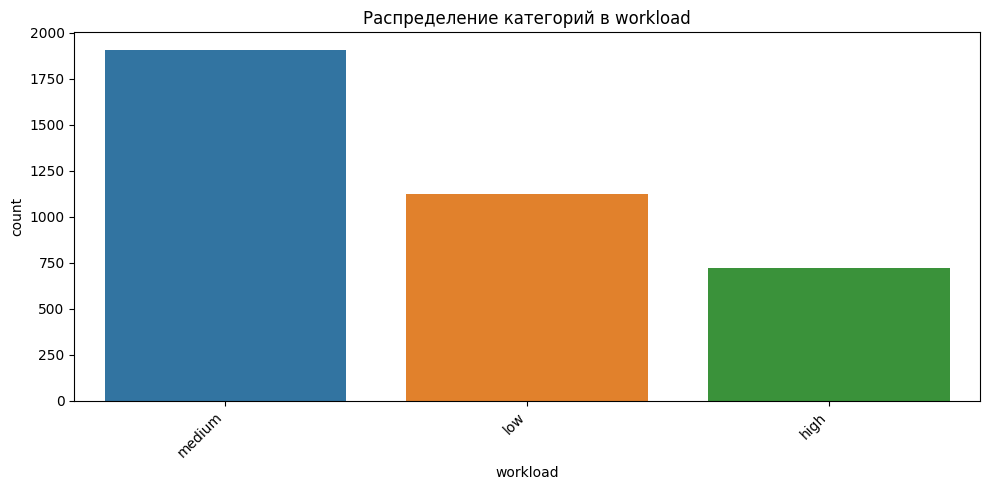

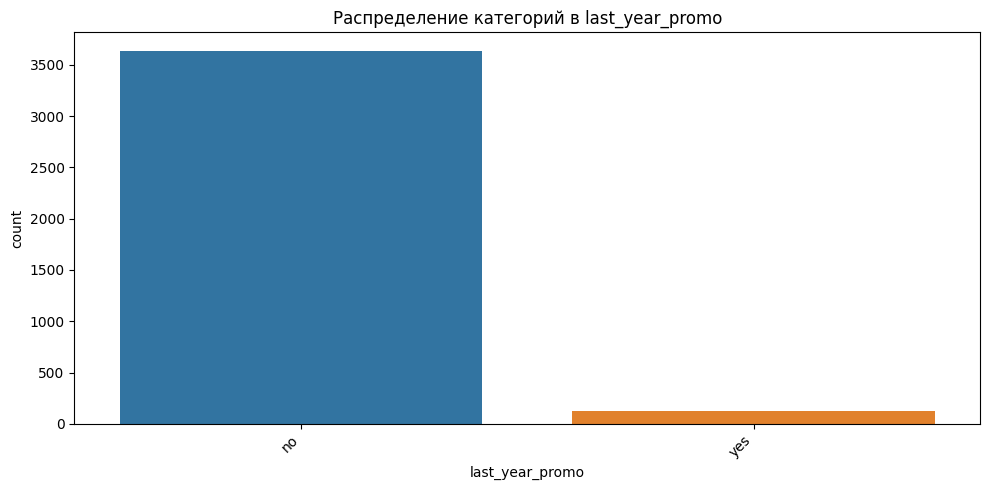

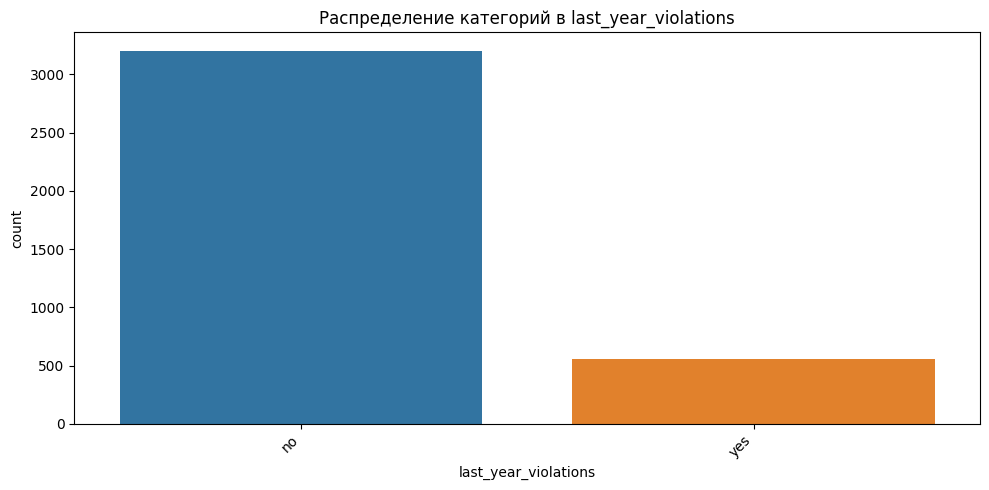

In [22]:
stat_analytics(df_train_features)

Видны количественные столбцы, значения которых носят дискретный характер - `employment_years`, `supervisor_evaluation`, построим отдельные графики - типа countplot:

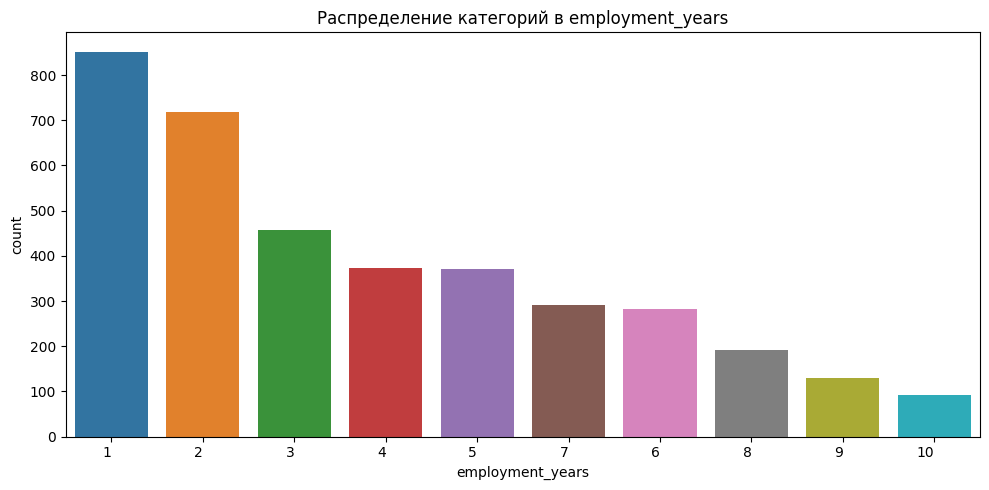

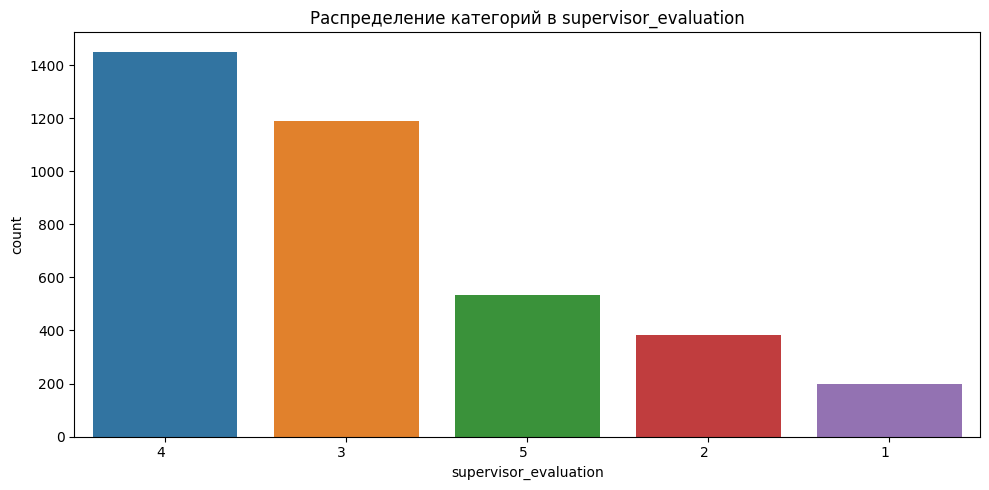

In [23]:
discret_col = ['employment_years', 'supervisor_evaluation']

for col in discret_col:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=df_train_features, order=df_train_features[col].value_counts().index)
    plt.title(f'Распределение категорий в {col}')
    plt.xticks(rotation=0, ha='right')
    plt.tight_layout()
    plt.show()

## Выводы по `df_train_features`
1. `employment_years` (длительность работы в компании) - заметно, что подавляющее число работников имеют стаж от 1 до 3 лет. В пайплайне этот столбец закодируем с помощью OrdinalEncoder.
2. `supervisor_evaluation` (оценка качества работы сотрудника, которую дал руководитель) - подавляющая масса оценок - 3 и 4 по 5-бальной шкале, значительно реже встречаются неудовлетворительные оценки - 1 и 2, идеальной оценки добились также небольшое количество сотрудников. Также OrdinalEncoder.
3. `salary` (ежемесячная зарплата сотрудника) - диапазон от 12 до 98 тысяч рублей, медианная зарплата - 30 т.руб. Возможно, потребуется разделить этот признак на людей с высокими и низкими зарплатами, потому что наблюдается большое количество выбросов. Кодировать будем StandardScaler либо MinMaxScaler.
4. `job_satisfaction_rate` (уровень удовлетворённости сотрудника работой в компании, целевой признак) - видим, что основные оценки сотрудников лежат в диапазоне от 0.36 до 0.71. Целевой признак, не кодируем.
5. `dept` (отдел, в котором работает сотрудник) - видно, что подавляющее число сотрудников занято в sales, остальные категории распределены примерно поровну. Кодируем OHE.
6. `level` (уровень занимаемой должности) - работников уровня junior и middle подавляющее количество, что соотносится с распределением длительности работы в компании и логически обосновано (не могут в одной компании все быть уровня Senior). Закодируем с помощью OrdinalEncoderю
7. `workload` (уровень загруженности сотрудника) - преобладает загруженность среднего (medium) уровня. Кодируем с помощью OHE.
8. `last_year_promo` (показывает, было ли повышение за последний год) - явное преобладание категории `no`, кодируем OHE.
9. `last_year_violations`(показывает, нарушал ли сотрудник трудовой договор за последний год) - аналогично `last_year_promo`.

In [24]:
df_train_features['salary'].median()

31200.0

,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000
mean,3.666500,3.526500,34066.800000
std,2.537222,0.996892,15398.436729
min,1.000000,1.000000,12000.000000
25%,1.000000,3.000000,22800.000000
50%,3.000000,4.000000,30000.000000
75%,6.000000,4.000000,43200.000000
max,10.000000,5.000000,96000.000000



Визуализация распределения количественных признаков


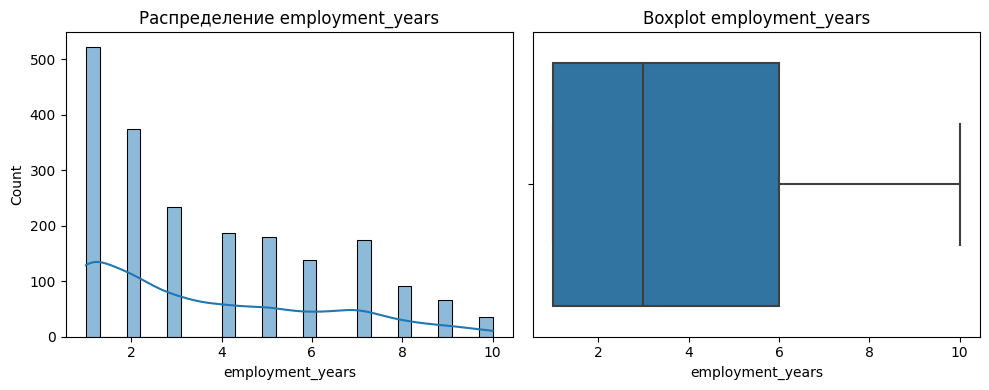

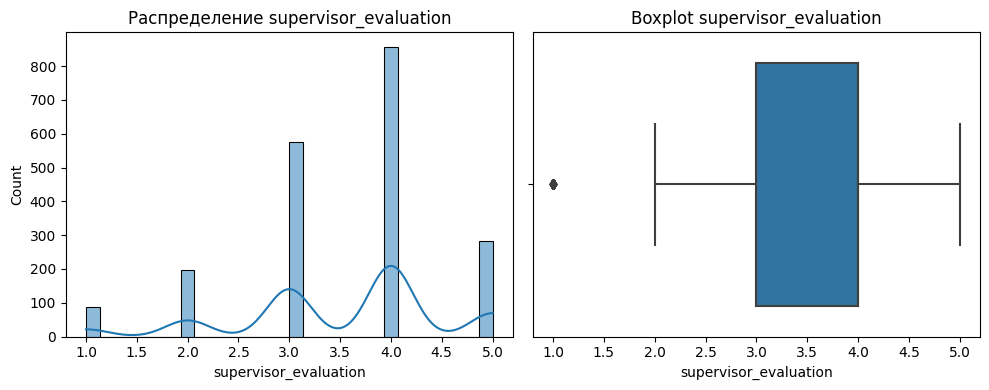

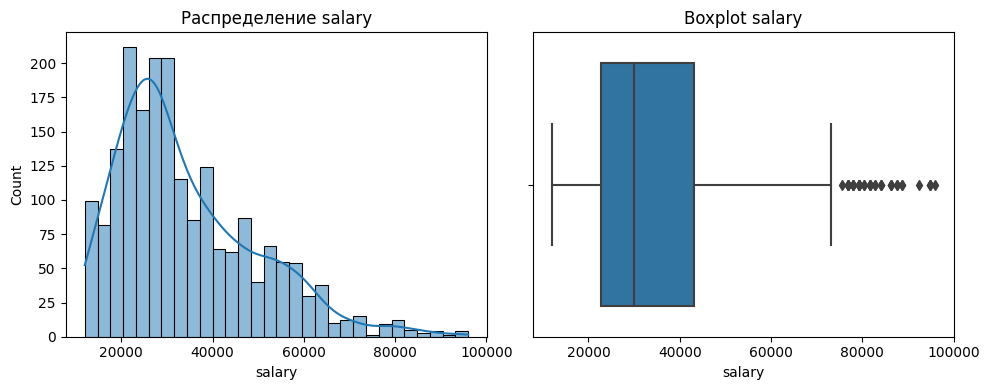


Визуализация распределения категориальных признаков


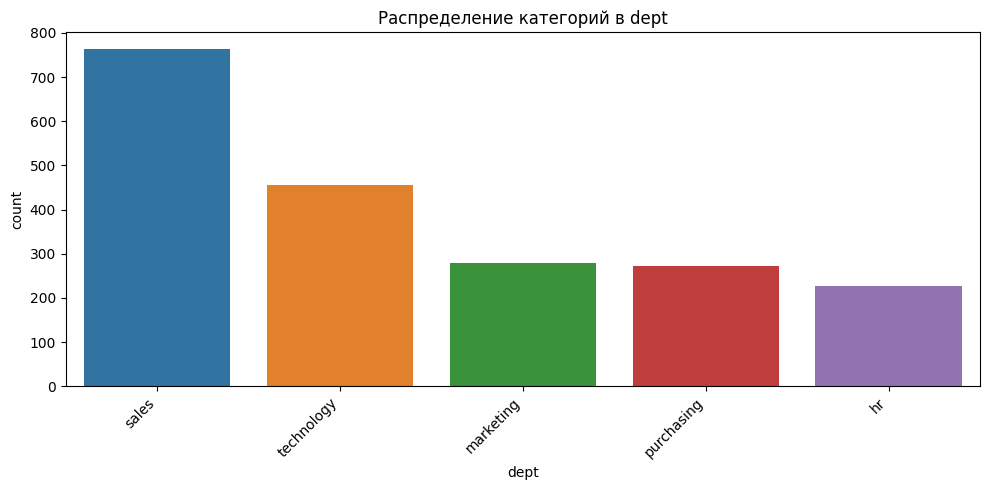

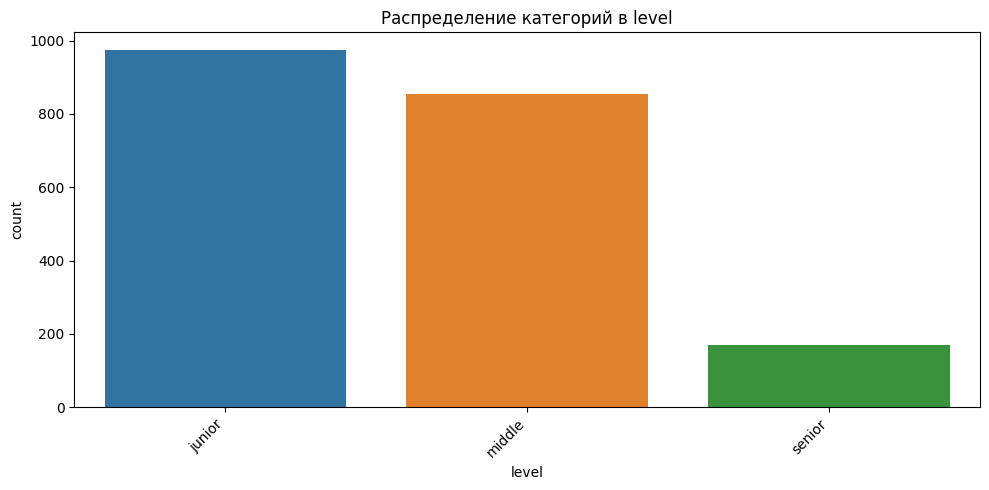

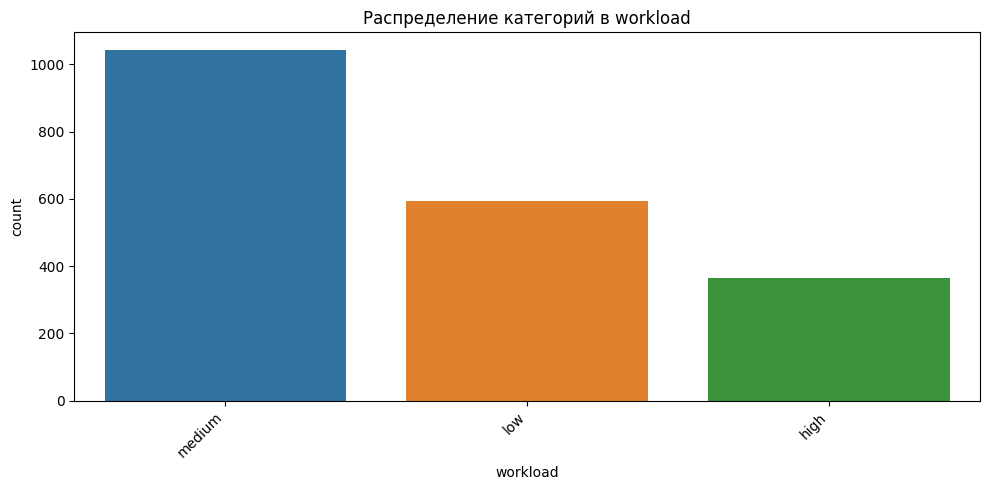

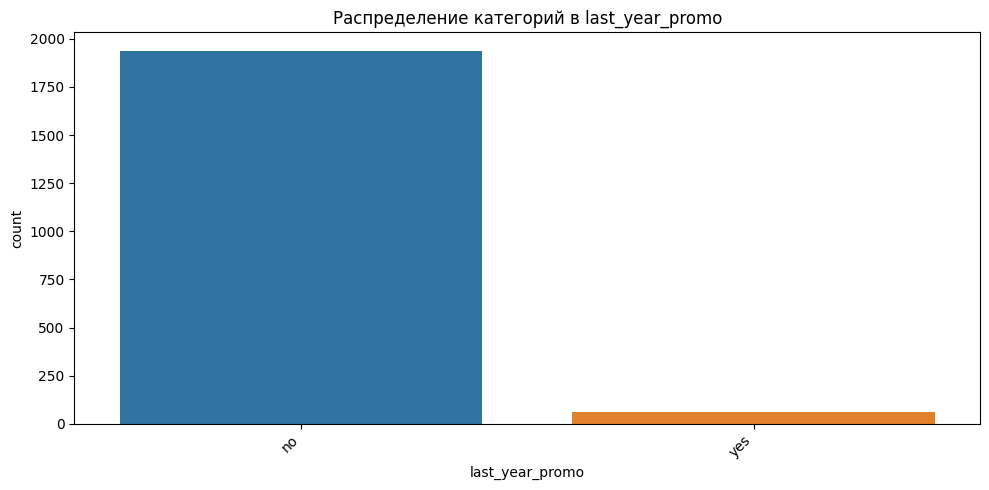

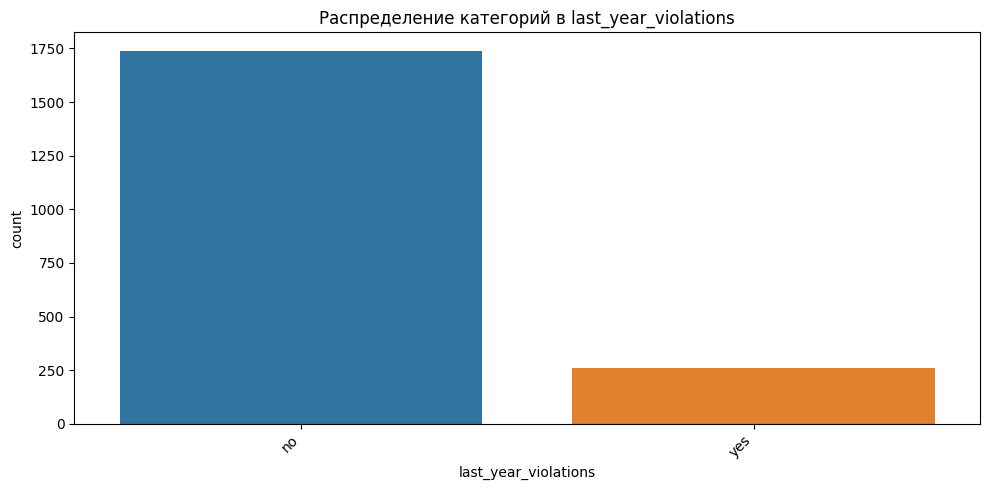

In [25]:
stat_analytics(df_test_features)

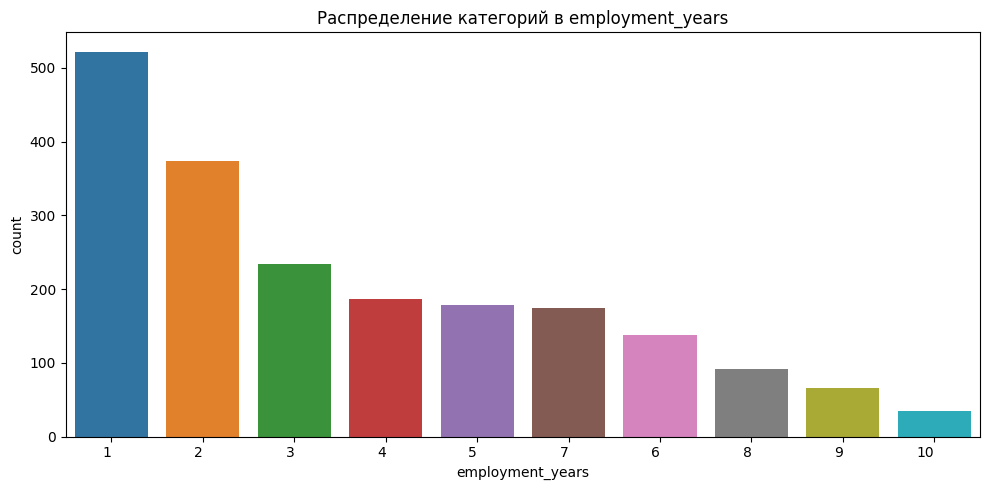

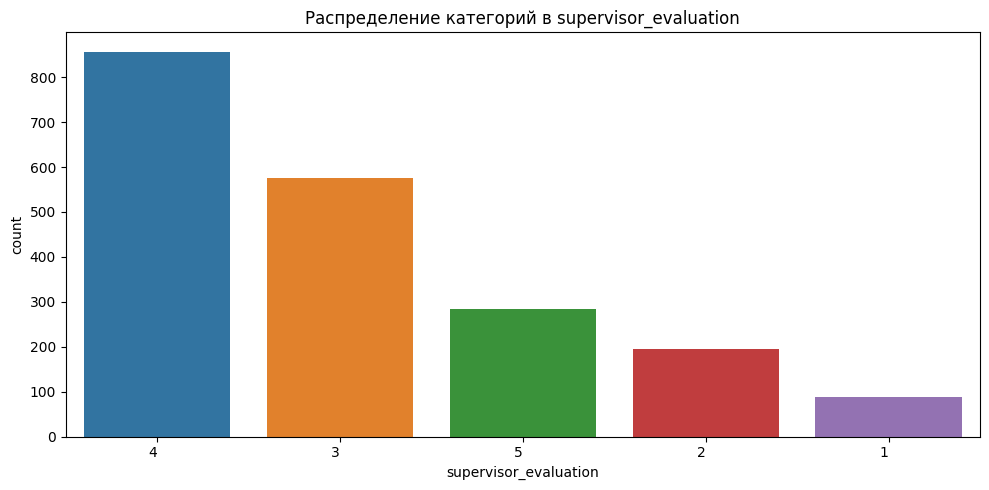

In [26]:
discret_col = ['employment_years', 'supervisor_evaluation']

for col in discret_col:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=df_test_features, order=df_test_features[col].value_counts().index)
    plt.title(f'Распределение категорий в {col}')
    plt.xticks(rotation=0, ha='right')
    plt.tight_layout()
    plt.show()

Видим, что в тестовой выборке распределение значений признаков аналогично тренировочной выборке, так что для него справедливы все те выводы, которые были сделаны для тренировочной.

Проверим распределение целевого признака из файла `df_target`:

,job_satisfaction_rate
count,2000.00000
mean,0.54878
std,0.22011
min,0.03000
25%,0.38000
50%,0.58000
75%,0.72000
max,1.00000



Визуализация распределения количественных признаков


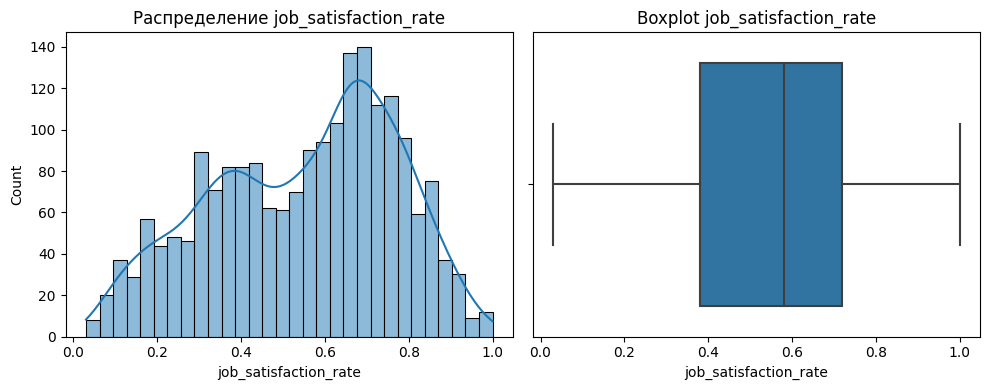


Визуализация распределения категориальных признаков


In [27]:
stat_analytics(df_target)

Оно также аналогично распределению из тренировочной выборки.

# Проведём корреляционный анализ:

In [28]:
df_train_features_ml = df_train_features.set_index('id')
corr_matrix_tr = df_train_features_ml.phik_matrix(interval_cols=['employment_years', 'job_satisfaction_rate',
                                                   'salary', 'supervisor_evaluation	'
                                                   ])
#'eval_above_avg_dept', 'salary_vs_level'

In [29]:
df_train_features_ml.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20


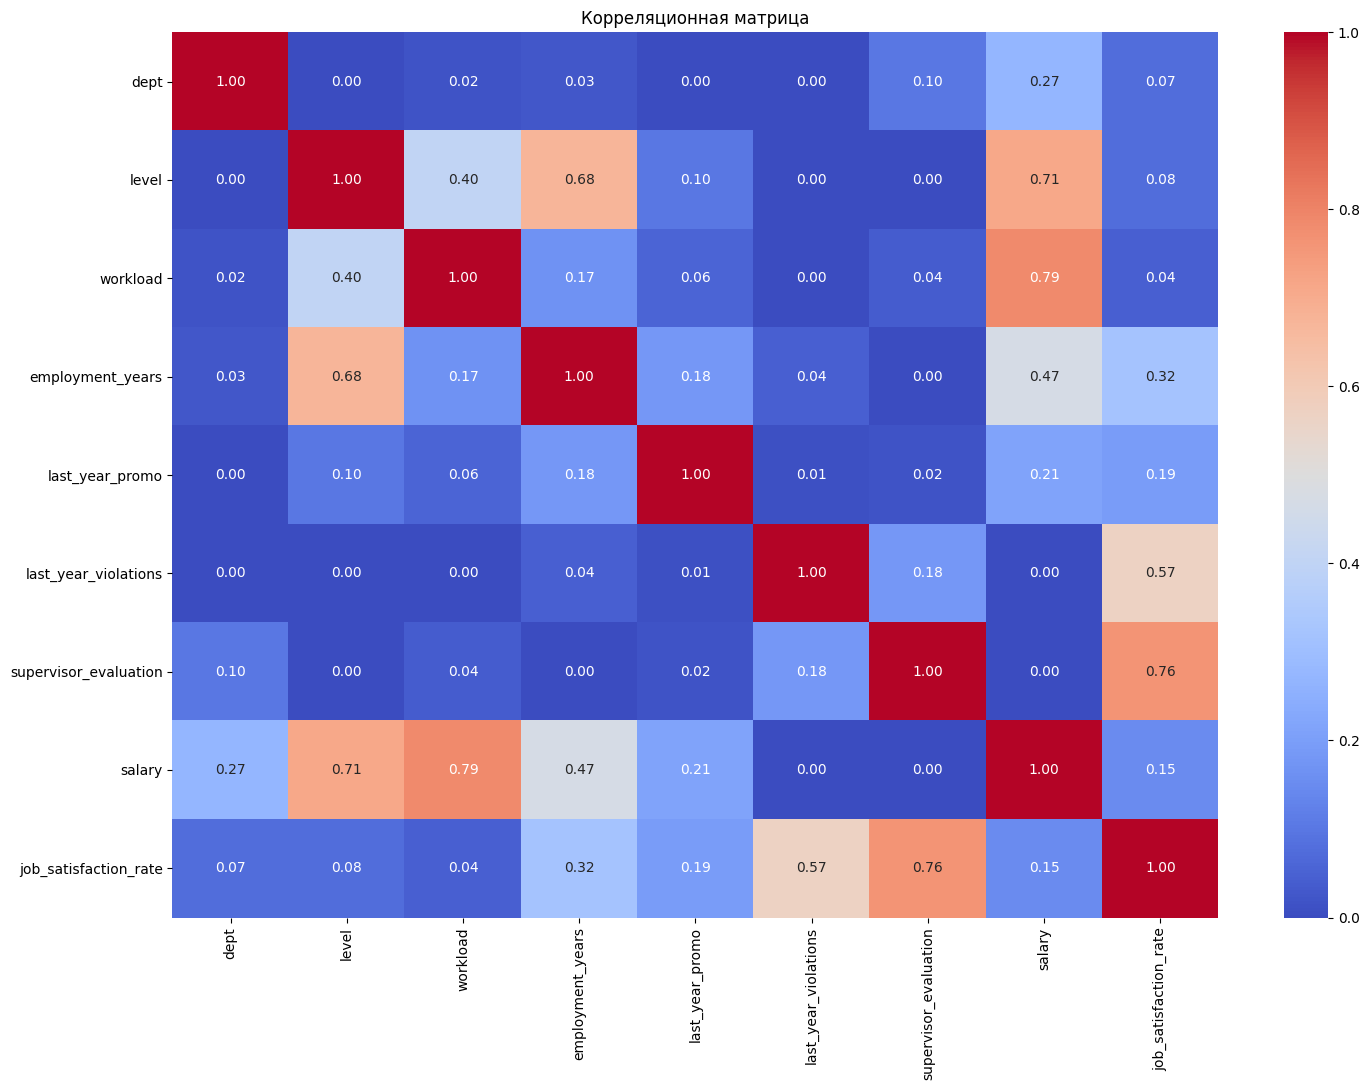

In [30]:
# визуализируем
plt.figure(figsize=(15, 11))
sns.heatmap(corr_matrix_tr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

interval columns not set, guessing: ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']
Топ-5 признаков по зависимости от 'job_satisfaction_rate':

supervisor_evaluation    0.762964
last_year_violations     0.566993
employment_years         0.319331
last_year_promo          0.191464
salary                   0.149599
Name: job_satisfaction_rate, dtype: float64


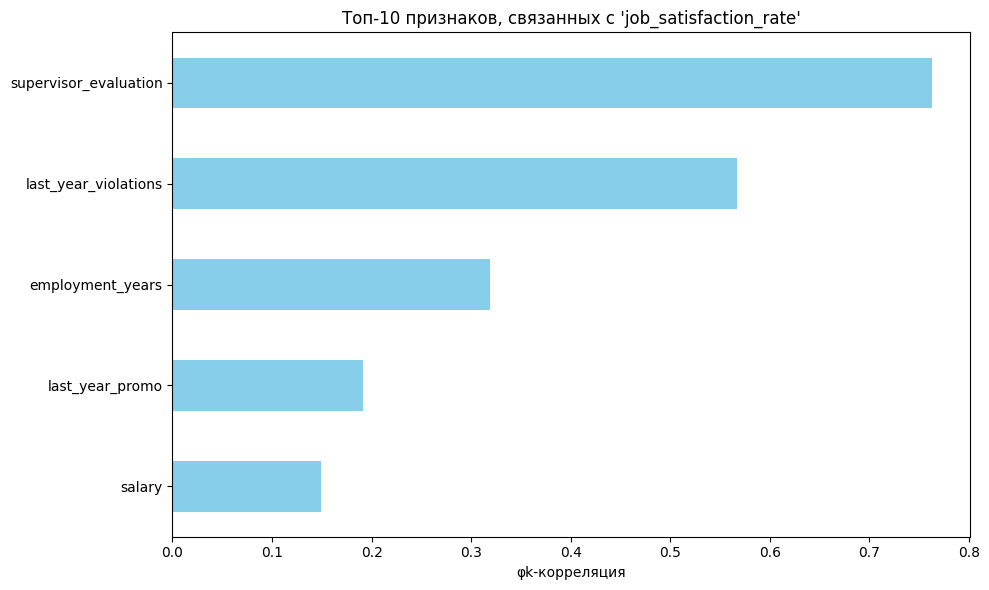

In [31]:
df_corr = df_train_features_ml.dropna(subset=['job_satisfaction_rate'])

# 2. Вычисление φk-корреляций
phik_corr = df_corr.phik_matrix(interval_cols=None)

# 3. Отберем зависимости с целевой переменной
target_corr = phik_corr['job_satisfaction_rate'].sort_values(ascending=False)

# 4. Выведем топ-10 признаков
print("Топ-5 признаков по зависимости от 'job_satisfaction_rate':\n")
print(target_corr.drop('job_satisfaction_rate').head(5))

# 5. Визуализация
plt.figure(figsize=(10, 6))
target_corr.drop('job_satisfaction_rate').head(5).plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title("Топ-10 признаков, связанных с 'job_satisfaction_rate'")
plt.xlabel("φk-корреляция")
plt.tight_layout()
plt.show();

## Выводы по корреляционному анализу
Уровень удовлетворённости сотрудника работой в компании сильно коррелирует с:
   - **оценкой качества работы сотрудника**, которую дал руководитель (`supervisor_evaluation`) - 0.76,
   - **нарушал ли сотрудник трудовой договор** за последний год (`last_year_violations`) - 0.56,
   - **длительностью работы в компании** (`employment_years`) - 0.32,
   - **было ли повышение за последний год** (`last_year_promo`) - 0.19,
   - **зарплатой** (`salary`) - 0.16

# Создание пайплайна

Подготовим данные:

In [32]:
df_test_features.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [33]:
df_train_features_ml.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20


In [34]:
df_test_features = pd.merge(df_test_features, df_target, on='id', how='inner')

In [35]:
X = df_train_features_ml.drop('job_satisfaction_rate', axis=1)
y = df_train_features_ml['job_satisfaction_rate']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=RANDOM_STATE
)


In [36]:
# группы признаков
num_features = ['salary', 'employment_years', 'supervisor_evaluation']
bin_features = ['last_year_promo', 'last_year_violations']
cat_features = ['dept', 'workload']
ord_features = ['level']

ordinal_categories = [
    ['junior', 'middle', 'senior']
]



num_trf = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    # Сначала масштабируем, чтобы взаимодействия были в схожих диапазонах
    ('sc',  RobustScaler())
])

bin_trf = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='if_binary'))
])

cat_trf = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ord_trf = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(categories=ordinal_categories))
])



preprocessor = ColumnTransformer([
    ('num', num_trf,  num_features),
    ('bin', bin_trf,  bin_features),
    ('cat', cat_trf,  cat_features),
    ('ord', ord_trf,  ord_features)
], remainder='passthrough')

# Итоговый пайплайн для линейной модели
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('models', LinearRegression())
])

# 2. Дерево решений с подбором гиперпараметров
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Параметры для GridSearch
param_grid = {
    'regressor__max_depth': [4, 5, 6, 7, 8], # Убрали None, ограничили глубину
    'regressor__min_samples_split': [15, 20, 30, 40], # Значительно увеличили
    'regressor__min_samples_leaf': [10, 15, 20, 25], # Значительно увеличили
    'regressor__max_features': ['sqrt', 'log2', 0.7, 0.8] # Используем долю признаков вместо None
}

# Функция SMAPE (для оценки)

def smape(y_true, y_pred):
    denom = (abs(y_true) + abs(y_pred)) / 2
    diff = abs(y_true - y_pred)
    return (diff / denom).mean() * 100

# Обёртка в виде scorer (для cross_val_score)
smape_scorer = make_scorer(smape, greater_is_better=False)

Обучим сначала линейную модель, затем модель дерева решений:

In [37]:
# Обучение линейной модели
linear_pipeline.fit(X_train, y_train)

# Кросс-валидация на train (5 фолдов)
cv_scores = cross_val_score(
    linear_pipeline,
    X_train,
    y_train,
    scoring=smape_scorer,
    cv=5
)

print(f"Средний SMAPE на кросс-валидации: {-cv_scores.mean():.2f}%")

Средний SMAPE на кросс-валидации: 25.33%


In [38]:
# Предсказание
y_pred_lr = linear_pipeline.predict(X_test)

# SMAPE на hold-out
print(f"SMAPE на hold-out (test): {smape(y_test, y_pred_lr):.2f}%")

SMAPE на hold-out (test): 24.67%


In [39]:
linear_pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   RobustScaler())]),
                                                  ['salary', 'employment_years',
                                                   'supervisor_evaluation']),
                                                 ('bin',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary'))]),
                                                  ['last...
                                                   'last_year_violations']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'workload']),
                                                 ('ord',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['junior',
                                                                                               'middle',
                                                                                               'senior']]))]),
                                                  ['level'])])),
                ('models', LinearRegression())])

In [40]:
# Обработка test_features, если она ещё не преобразована
y_public_lr = linear_pipeline.predict(df_test_features)

# Выводим SMAPE на тесте
print(f"SMAPE на публичном тесте: {smape(df_test_features['job_satisfaction_rate'], y_public_lr):.2f}%")

SMAPE на публичном тесте: 23.58%


In [41]:
gcv = GridSearchCV(
    tree_pipeline,            # ваш pipe с DecisionTreeRegressor
    param_grid,
    cv=5,
    scoring=smape_scorer,
    n_jobs=-1,
    verbose=1
)
gcv.fit(X_train, y_train)

print("Лучшая конфигурация:", gcv.best_params_)
print("Средний SMAPE (CV): ", -gcv.best_score_)

# 2. Проверяем на hold‑out 
y_pred_holdout = gcv.predict(X_test)
print("SMAPE на hold‑out:", smape(y_test, y_pred_holdout))

# 3. Финальное дообучение 
best_tree = gcv.best_estimator_
best_tree.fit(X, y)           # всё тренировочное

# 4. Итоговый тест из задания 
y_public_pred = best_tree.predict(df_test_features)
print("SMAPE на паблик‑тесте:",
      smape(df_test_features['job_satisfaction_rate'], y_public_pred))

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Лучшая конфигурация: {'regressor__max_depth': 8, 'regressor__max_features': 0.8, 'regressor__min_samples_leaf': 10, 'regressor__min_samples_split': 30}
Средний SMAPE (CV):  18.22502752228604
SMAPE на hold‑out: 17.606571867996045
SMAPE на паблик‑тесте: 16.777739706202993


Добавим новые параметры в датасеты:
- `eval_above_avg_dept` - насколько оценка руководителя выше среднего по отделу (влияет на мотивацию).
- `salary_vs_level` - отношение зарплаты к среднему для уровня (несправедливость/переоценка).

И сразу же проверим корреляцию для новых признаков.

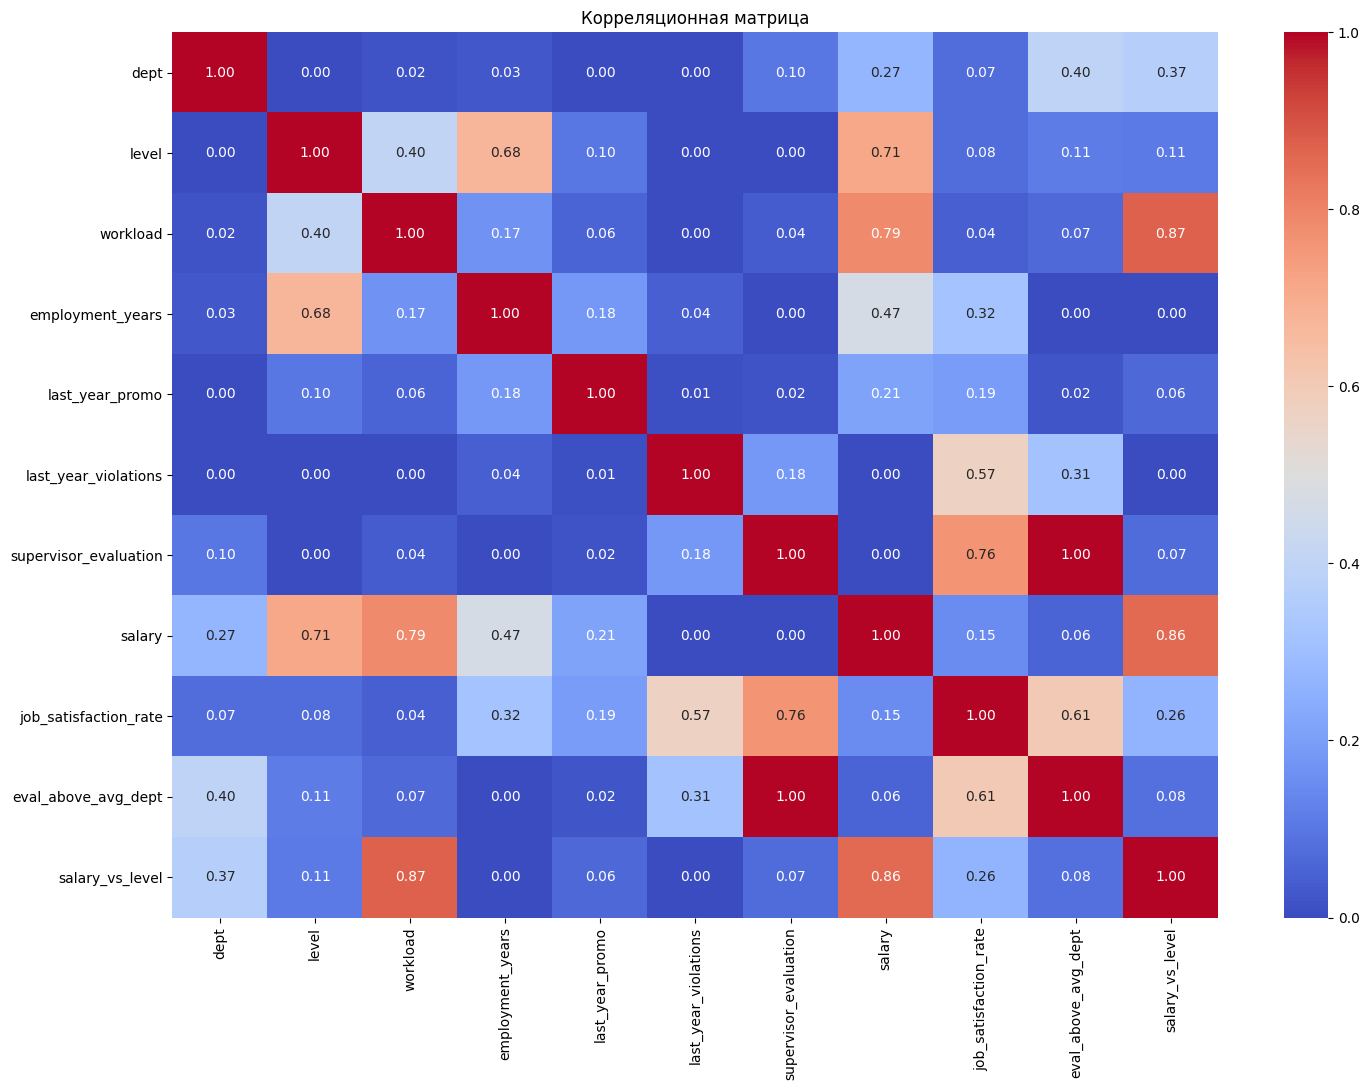

In [42]:
# Копируем списки признаков (добавим в них новые)
num_features_extended = num_features.copy()
bin_features_extended = bin_features.copy()

# 1. Оценка выше среднего по dept
mean_eval_by_dept = df_train_features_ml.groupby('dept')['supervisor_evaluation'].mean().to_dict()
df_train_features_ml['eval_above_avg_dept'] = (
    df_train_features_ml['supervisor_evaluation'] - df_train_features_ml['dept'].map(mean_eval_by_dept)
)
df_test_features['eval_above_avg_dept'] = (
    df_test_features['supervisor_evaluation'] - df_test_features['dept'].map(mean_eval_by_dept)
)
num_features_extended.append('eval_above_avg_dept')

# 2. Зарплата относительно уровня
mean_salary_by_level = df_train_features_ml.groupby('level')['salary'].mean().to_dict()
df_train_features_ml['salary_vs_level'] = (
    df_train_features_ml['salary'] / df_train_features_ml['level'].map(mean_salary_by_level)
)
df_test_features['salary_vs_level'] = (
    df_test_features['salary'] / df_test_features['level'].map(mean_salary_by_level)
)
num_features_extended.append('salary_vs_level')


#  Корреляционная матрица phik 



df_corr = df_train_features_ml.copy()
df_corr['job_satisfaction_rate'] = y

# phik корректно работает с числовыми колонками, укажем их явно
numeric_cols = num_features_extended.copy()
target_col = ['job_satisfaction_rate']

# Считаем матрицу корреляции phik
phik_matrix = df_corr.phik_matrix(interval_cols=numeric_cols + target_col)

# визуализируем
plt.figure(figsize=(15, 11))
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

Новые признаки показывают неплохую корреляцию с целевым признаком, `salary_vs_level` - 0.24, `eval_above_avg_dept` - 0.61.
Далее проверим работу дерева решений (т.к. SMAPE у него на паблик-тесте был выше) с новыми признаками, также изменим гиперпараметры дерева решений:

In [43]:
X = df_train_features_ml.drop('job_satisfaction_rate', axis=1)
y = df_train_features_ml['job_satisfaction_rate']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=RANDOM_STATE
)


In [44]:
preprocessor = ColumnTransformer([
    ('num', num_trf,  num_features_extended), # добавили новые признаки
    ('bin', bin_trf,  bin_features_extended), 
    ('cat', cat_trf,  cat_features),
    ('ord', ord_trf,  ord_features)
], remainder='passthrough')

# Параметры для GridSearch
param_grid = {
    'regressor__max_depth': [4, 6, 8, 10, 12, 15], # Убрали None, ограничили глубину
    'regressor__min_samples_split': [10, 15, 20, 25, 30], # Значительно увеличили
    'regressor__min_samples_leaf': [5, 10, 15, 20], # Значительно увеличили
    'regressor__max_features': ['sqrt', 'log2',0.6, 0.7, 0.8, 0.9] # Используем долю признаков вместо None
}


In [45]:
gcv = GridSearchCV(
    tree_pipeline,            # ваш pipe с DecisionTreeRegressor
    param_grid,
    cv=5,
    scoring=smape_scorer,
    n_jobs=-1,
    verbose=1
)
gcv.fit(X_train, y_train)

print("Лучшая конфигурация:", gcv.best_params_)
print("Средний SMAPE (CV): ", -gcv.best_score_)

# ---- 2. Проверяем на hold‑out ----
y_pred_holdout = gcv.predict(X_test)
print("SMAPE на hold‑out:", smape(y_test, y_pred_holdout))

# ---- 3. Финальное дообучение ----
best_tree = gcv.best_estimator_
best_tree.fit(X, y)           # всё тренировочное

# ---- 4. Итоговый тест из задания ----
y_public_pred = best_tree.predict(df_test_features)
print("SMAPE на паблик‑тесте:",
      smape(df_test_features['job_satisfaction_rate'], y_public_pred))

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Лучшая конфигурация: {'regressor__max_depth': 12, 'regressor__max_features': 0.7, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 10}
Средний SMAPE (CV):  15.64586733292045
SMAPE на hold‑out: 15.18924148809907
SMAPE на паблик‑тесте: 14.274593551608069


Удалось добиться целевой метрики SMAPE - 14.27

In [46]:
df = df_train_features_ml.copy()


X_dummy = df.drop('job_satisfaction_rate', axis=1)
y_dummy = df['job_satisfaction_rate']


X_train_dummy, X_test_dummy, y_train_dummy, y_test_dummy = train_test_split(
    X_dummy, y_dummy, random_state=RANDOM_STATE
)

dummy = DummyRegressor(strategy='mean')


dummy.fit(X_train_dummy, y_train_dummy)

y_pred_dummy = dummy.predict(X_test)

# Считаем SMAPE
print(f"SMAPE dummy-модели (среднее): {smape(y_test_dummy, y_pred_dummy):.2f}%")

SMAPE dummy-модели (среднее): 39.83%


## Выводы
DecisionTree оказалась более подходящей моделью для нашей задачи, чем LinearRegression, по нескольким причинам:
- Linear Regression строит зависимость между признаками и целевой переменной в виде прямой линии или плоскости. Если истинная связь между признаками и уровнем удовлетворённости работой (job_satisfaction_rate) нелинейна, или существуют сложные взаимодействия между признаками (например, влияние стажа зависит от отдела, или зарплаты от уровня), линейная регрессия не сможет адекватно это уловить.
- Decision Tree, напротив, является нелинейной моделью. Оно строит иерархическую структуру условий ("если то") на основе значений признаков. Каждое ветвление дерева по сути моделирует взаимодействие или нелинейную зависимость.
- Также, Decision Tree более устойчива к мультиколлинеарности. При построении дерева алгоритм на каждом шаге выбирает наилучший признак для разделения данных, основываясь на определённом критерии (например, уменьшении ошибки). Если два признака сильно коррелируют, дерево просто выберет один из них, который даст лучшее разделение на данном этапе.
- Меньшая чувствительность к выбросам в `salary` (благодаря RobustScaler и природе дерева). 

# Модель, прогнозирующая, уволится ли сотрудник в ближайшее время

Этапы выполнения задачи:
- Предобработка данных;
- Исследовательский анализ данных (EDA)
    - проведём исследовательский анализ данных;
    - составим портрет "уволившегося" сотрудника;
    - проверим влияние job_satisfaction_rate;
- Добавляем предсказанный job_satisfaction_rate;
- Подготовим пайплайн для обучения моделей
- Обучение моделей
- Оценка качества моделей и выводы

## Предобработка данных

Ранее мы уже загрузили необходимые файлы, познакомимся с датафреймами:

In [47]:
get_dataset_info(df_train_quit)


Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


None


Размер датасета (строки, столбцы):


'(4000, 10) (rows, cols)'


Первые строки данных:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


Данные аналогичны, видим бинарный признак quit. Проверим на наличие пропусков и явных и неявных дубликатов:

In [48]:
get_unique_values(df_train_quit)

[array(['sales', 'purchasing', 'marketing', 'technology', 'hr'],
       dtype=object),
 array(['middle', 'junior', 'sinior'], dtype=object),
 array(['high', 'medium', 'low'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object)]

Аналогично тому, что мы делали в задаче 1, исправим опечатку в столбце `level` - senior вместо sinior:

In [49]:
df_train_quit['level'] = df_train_quit['level'].replace({'sinior': 'senior'})

Проверим:

In [50]:
get_unique_values(df_train_quit)

[array(['sales', 'purchasing', 'marketing', 'technology', 'hr'],
       dtype=object),
 array(['middle', 'junior', 'senior'], dtype=object),
 array(['high', 'medium', 'low'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object)]

Замена прошла корректно.

Проверим целевой признак `df_test_target_quit`:

In [51]:
get_dataset_info(df_test_target_quit)


Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


None


Размер датасета (строки, столбцы):


'(2000, 2) (rows, cols)'


Первые строки данных:


,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


In [52]:
get_unique_values(df_test_target_quit)

[array(['yes', 'no'], dtype=object)]

Неявных дубликатов не обнаружено, проведём проверку на явные дубликаты и пропуски для обоих датасетов:

In [53]:
print('Проверка тренировочной выборки quit: \n')
check_duplicates_and_missing(df_train_quit)
print('Проверка целевого признака quit: \n')
check_duplicates_and_missing(df_test_target_quit)

Проверка тренировочной выборки quit: 

Количество дубликатов: 0
Количество пропусков: 0

Дубликаты и пропуски отсутствуют.
Проверка целевого признака quit: 

Количество дубликатов: 0
Количество пропусков: 0

Дубликаты и пропуски отсутствуют.


Проведём проверку без учёта `id`:

In [54]:
print('Проверка тренировочной выборки quit без учёта id: \n')
check_duplicates_and_missing(df_train_quit.drop(columns=['id']))

Проверка тренировочной выборки quit без учёта id: 

Количество дубликатов: 1413
Количество пропусков: 0


Избавимся от дубликатов:

In [55]:
features_quit = df_train_quit.columns.drop(['id'])  
df_train_quit = df_train_quit.drop_duplicates(subset=features_quit)

Проверим наличие дубликатов:

In [56]:
print('Проверка тренировочной выборки quit без учёта id: \n')
check_duplicates_and_missing(df_train_quit.drop(columns=['id']))

Проверка тренировочной выборки quit без учёта id: 

Количество дубликатов: 0
Количество пропусков: 0

Дубликаты и пропуски отсутствуют.


## Исследовательский анализ данных
- проведём исследовательский анализ данных;
- оставим портрет "уволившегося" сотрудника;
- проверим влияние job_satisfaction_rate;

Используем функцию для статистического анализа:

,employment_years,supervisor_evaluation,salary
count,2587.000000,2587.000000,2587.000000
mean,4.213375,3.367994,37107.692308
std,2.601105,1.080243,16267.354906
min,1.000000,1.000000,12000.000000
25%,2.000000,3.000000,24000.000000
50%,4.000000,3.000000,33600.000000
75%,6.000000,4.000000,46800.000000
max,10.000000,5.000000,96000.000000



Визуализация распределения количественных признаков


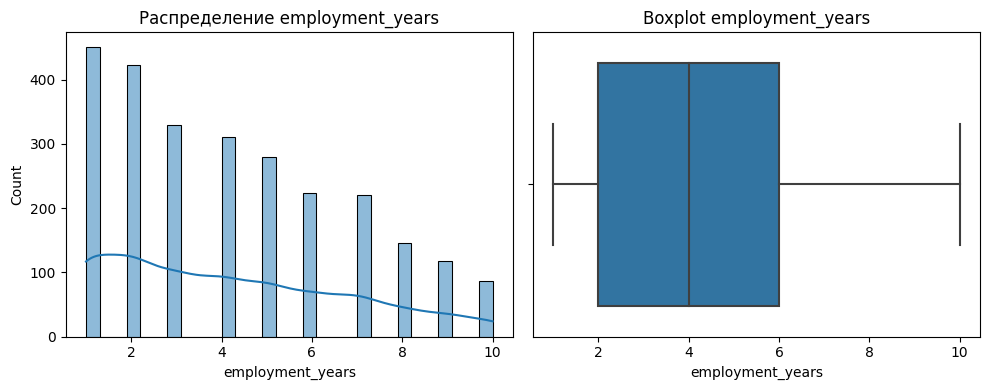

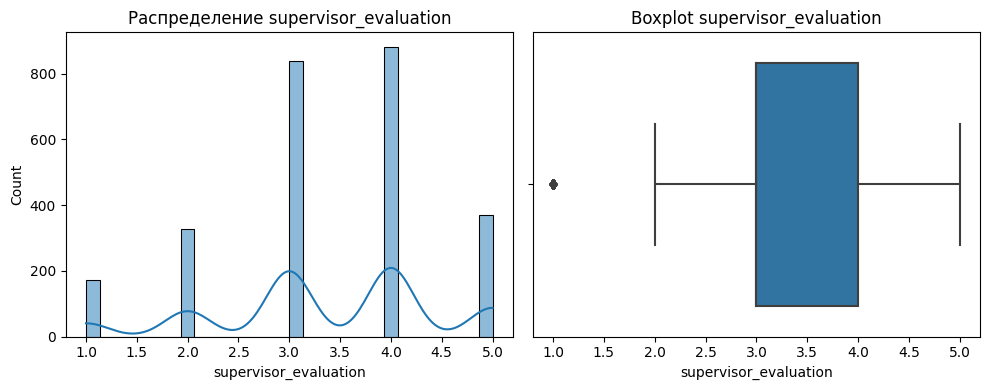

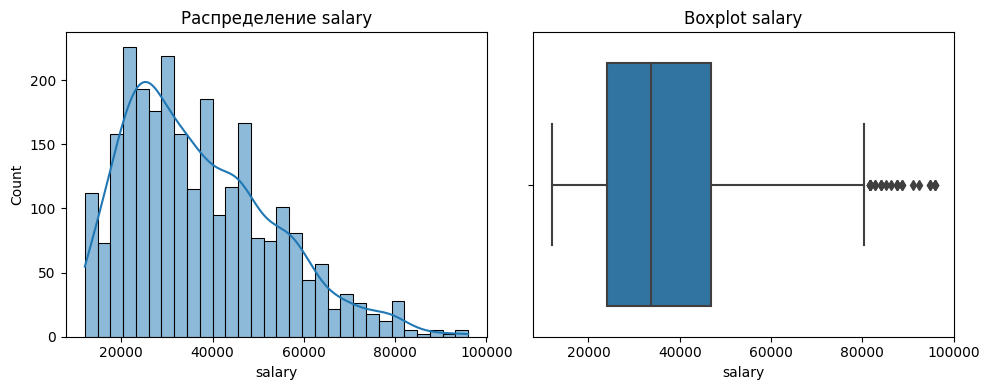


Визуализация распределения категориальных признаков


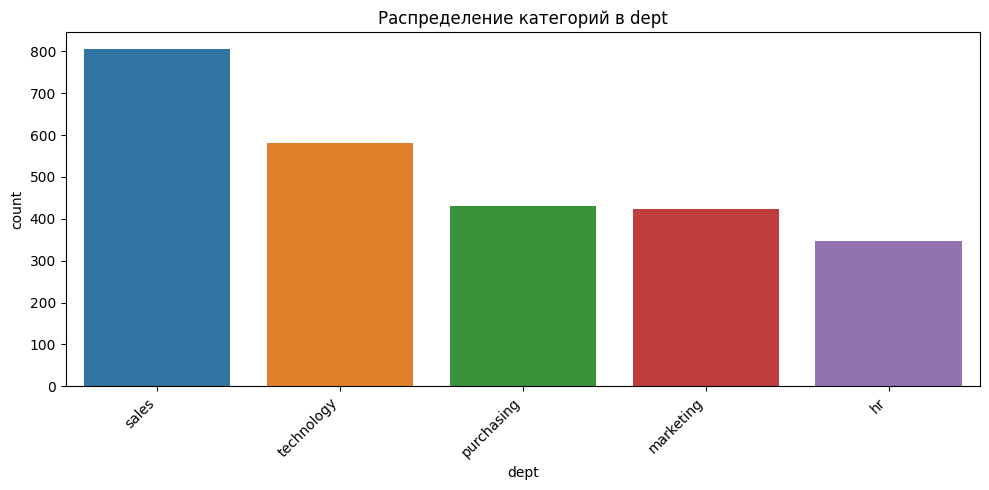

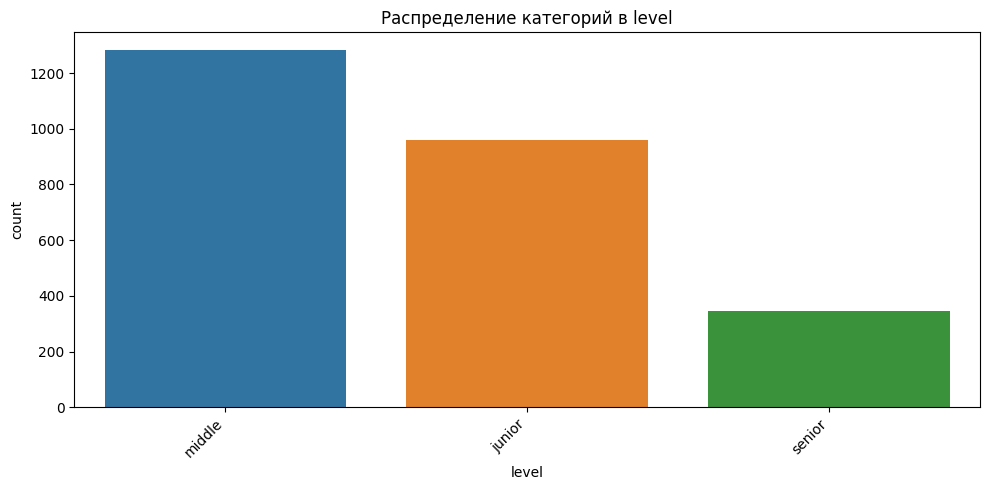

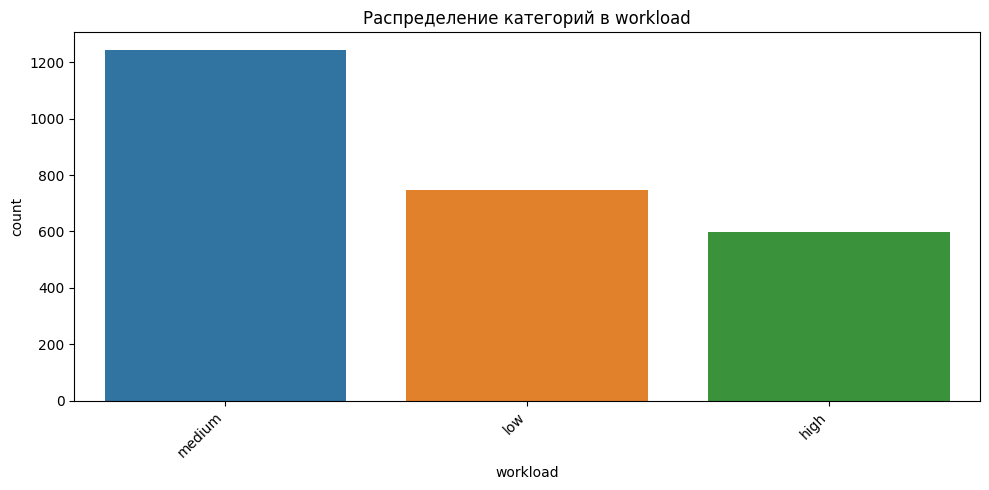

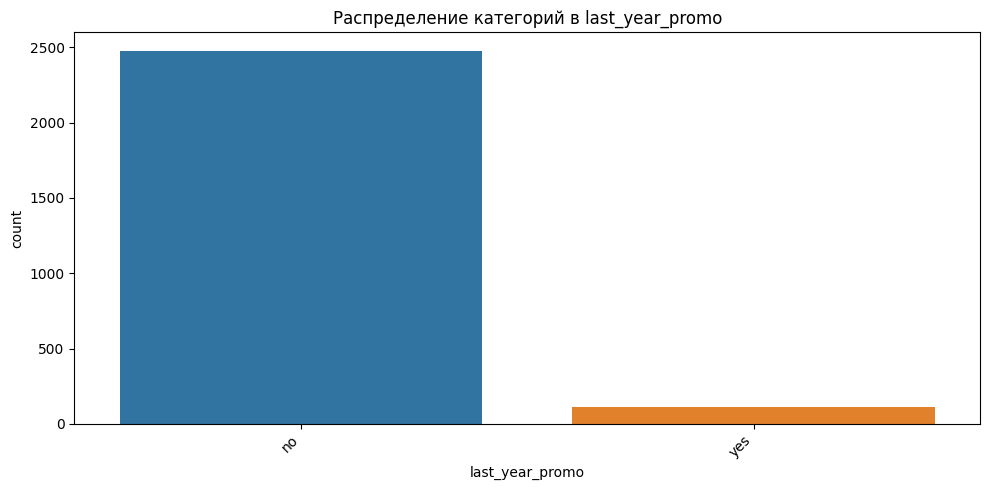

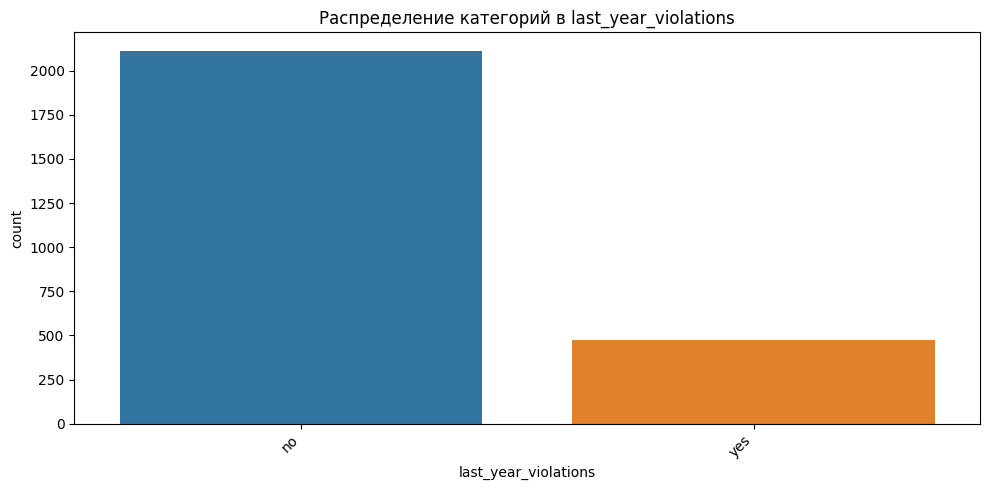

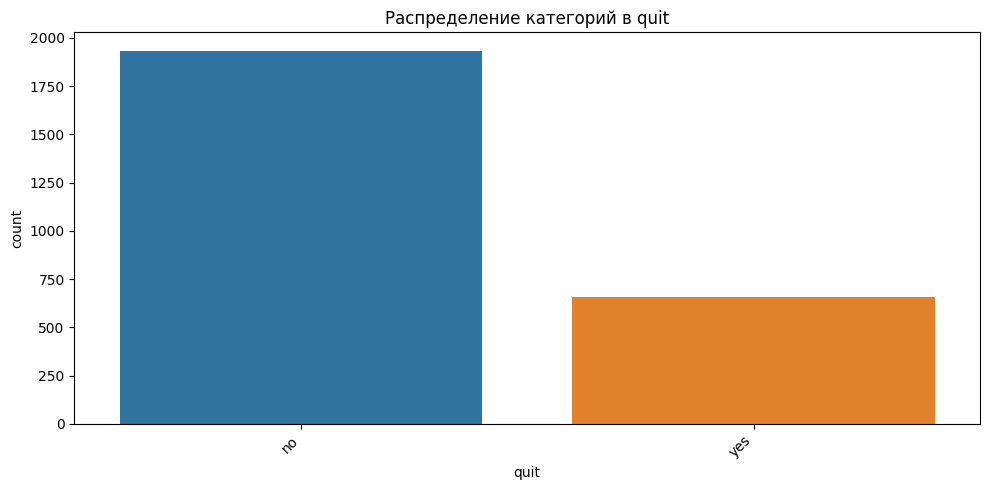

In [57]:
stat_analytics(df_train_quit)

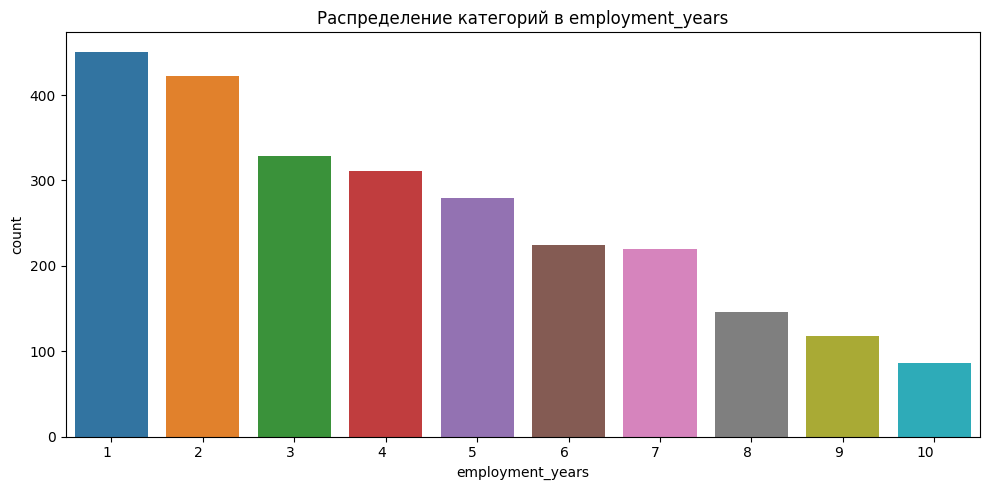

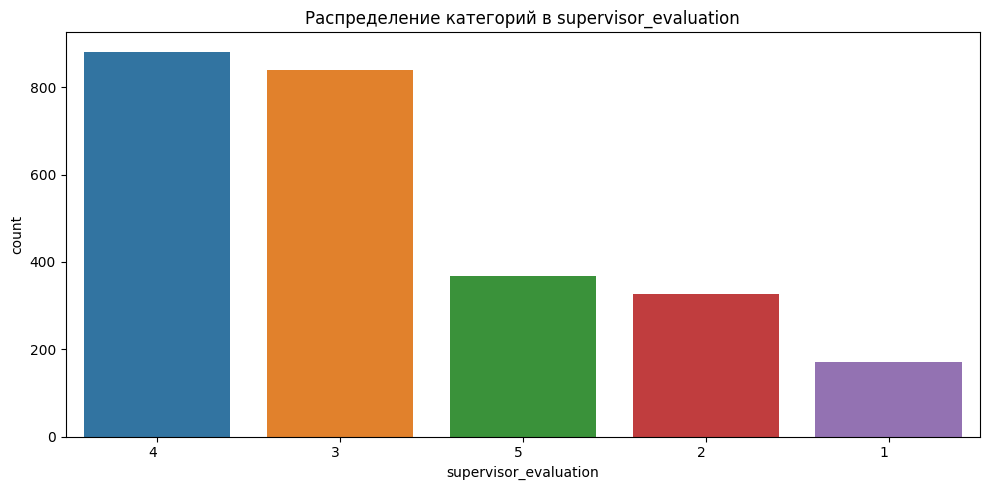

In [58]:
discret_col_quit = ['employment_years', 'supervisor_evaluation']

for col in discret_col_quit:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=df_train_quit, order=df_train_quit[col].value_counts().index)
    plt.title(f'Распределение категорий в {col}')
    plt.xticks(rotation=0, ha='right')
    plt.tight_layout()
    plt.show()

### Выводы по статистическому анализу
Видим аналогичное распределение значений признаков тому, что и в первой задаче, все выводы справедливы и для этого датасета. Отдельно отметим, что доля "неуволившихся" сотрудников значительно выше, чем "уволившихся". Присутствует дисбаланс классов, проверим распределение тестовой выборки целевой переменной:

,quit
count,2000
unique,2
top,no
freq,1436



Визуализация распределения количественных признаков

Визуализация распределения категориальных признаков


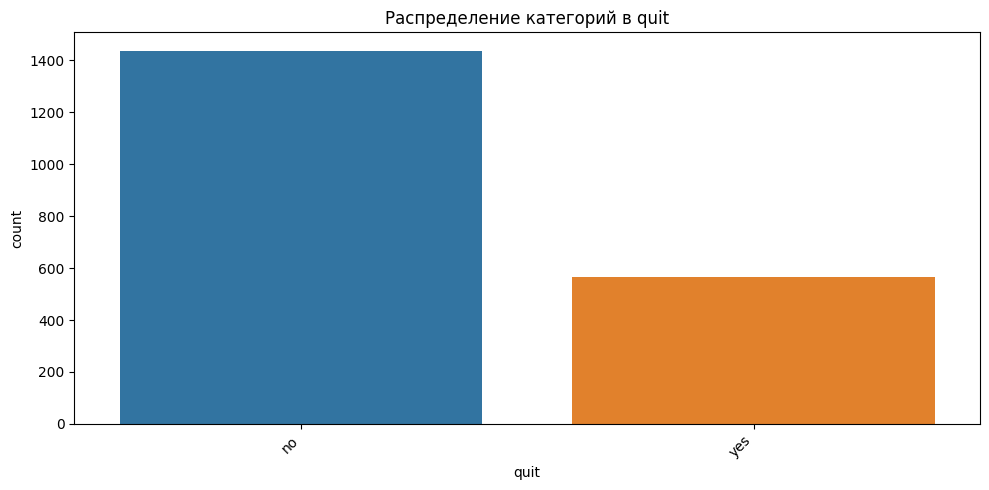

In [59]:
stat_analytics(df_test_target_quit)

Распределение аналогичное тому, что и в тренировочной выборке.

### Составим портрет "уволившегося" сотрудника:

In [60]:
df_train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


quit,no,yes,quit_rate
dept,,,
purchasing,310,120,0.279070
marketing,311,112,0.264775
technology,431,150,0.258176
sales,614,191,0.237267
hr,266,82,0.235632


quit,no,yes,quit_rate
workload,,,
low,455,291,0.390080
medium,989,255,0.204984
high,488,109,0.182580


quit,no,yes,quit_rate
level,,,
junior,421,537,0.560543
middle,1181,101,0.078783
senior,330,17,0.048991


quit,no,yes,quit_rate
supervisor_evaluation,,,
1,102,69,0.403509
2,203,123,0.377301
3,567,272,0.324195
4,734,148,0.167800
5,326,43,0.116531


quit,no,yes,quit_rate
last_year_violations,,,
yes,296,180,0.378151
no,1636,475,0.225012


quit,no,yes,quit_rate
employment_years,,,
1,175,276,0.611973
2,244,178,0.421801
3,201,128,0.389058
4,286,25,0.080386
5,258,22,0.078571
6,214,10,0.044643
10,83,3,0.034884
7,213,7,0.031818
9,115,3,0.025424


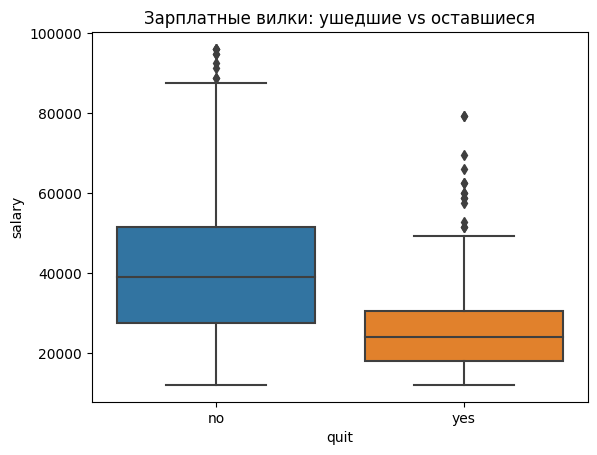

Средняя зарплата ушедших  : 25767.93893129771
Средняя зарплата оставшихся: 40952.17391304348


In [61]:
# Департамент + quit
dept_pivot = (df_train_quit
              .groupby(['dept', 'quit'])
              .size()
              .unstack(fill_value=0))
dept_pivot['quit_rate'] = dept_pivot['yes'] / dept_pivot.sum(axis=1)
display(dept_pivot.sort_values('quit_rate', ascending=False))

# Workload + quit
workload_pivot = (df_train_quit
                  .groupby(['workload', 'quit'])
                  .size()
                  .unstack(fill_value=0))
workload_pivot['quit_rate'] = workload_pivot['yes'] / workload_pivot.sum(axis=1)
display(workload_pivot.sort_values('quit_rate', ascending=False))

# Level + quit
level_pivot = (df_train_quit
              .groupby(['level', 'quit'])
              .size()
              .unstack(fill_value=0))
level_pivot['quit_rate'] = level_pivot['yes'] / level_pivot.sum(axis=1)
display(level_pivot.sort_values('quit_rate', ascending=False))

# supervisor_evaluation + quit
supervisor_evaluation_pivot = (df_train_quit
              .groupby(['supervisor_evaluation', 'quit'])
              .size()
              .unstack(fill_value=0))
supervisor_evaluation_pivot['quit_rate'] = supervisor_evaluation_pivot['yes'] / supervisor_evaluation_pivot.sum(axis=1)
display(supervisor_evaluation_pivot.sort_values('quit_rate', ascending=False))

last_year_violations_pivot = (df_train_quit
              .groupby(['last_year_violations', 'quit'])
              .size()
              .unstack(fill_value=0))
last_year_violations_pivot['quit_rate'] = last_year_violations_pivot['yes'] / last_year_violations_pivot.sum(axis=1)
display(last_year_violations_pivot.sort_values('quit_rate', ascending=False))

employment_years_pivot = (df_train_quit
              .groupby(['employment_years', 'quit'])
              .size()
              .unstack(fill_value=0))
employment_years_pivot['quit_rate'] = employment_years_pivot['yes'] / employment_years_pivot.sum(axis=1)
display(employment_years_pivot.sort_values('quit_rate', ascending=False))

# Зарплата
sns.boxplot(data=df_train_quit, x='quit', y='salary')
plt.title('Зарплатные вилки: ушедшие vs оставшиеся')
plt.show()

print('Средняя зарплата ушедших  :', df_train_quit.loc[df_train_quit.quit=='yes', 'salary'].mean())
print('Средняя зарплата оставшихся:', df_train_quit.loc[df_train_quit.quit=='no',  'salary'].mean())

### Выводы по портрету "уволившегося" клиента
Этот сотрудник с высокой долей вероятности:
- недополучал зарплату (средняя зарплата 23885 против 37702);
- работал в отделе technology (низкая оплата для высококвалифицированной деятельности);
- имел low уровень по рабочей нагрузке (не мог самореализоваться на работе, получал мало задач, что соответсвует низкому уровню оплаты)

Дополнение к портрету "уволившегося" сотрудника:
- скорее всего - junior;
- получал низкие оценки от руководителей (1-2);
- и нарушавший трудовой договор за последний год.
- работал 1-3 года.

В итоге, портрет "уволившегося" сотрудника следующий: молодой специалист, пришедший в компанию "заряженным" на свершения, столкнувшийся с низкой оценкой качества его труда как социально (от руководителя), так и материально (недополучает денег). Ему дают мало задач и скорее всего это расслабляет человека и вынуждает нарушать трудовой договор за счёт систематических опозданий, ранних уходов и т.д. и в итоге такой специалист задерживается в компании всего на 1-3 года, набивает опыт и идёт дальше. 

## Оценка влияния `job_satisfaction_rate`

Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверим это утверждение: визуализируем и сравним распределения признака `job_satisfaction_rate` для ушедших и оставшихся сотрудников. Используем данные с обоими целевыми признаками тестовой выборки.

In [62]:
# Объединяем все данные по id
df_test_full = (
    df_test_features
    .merge(df_target, on='id')            # добавим job_satisfaction_rate
    .merge(df_test_target_quit, on='id')  # добавим quit
)

In [63]:
print(df_test_full.columns)

Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary', 'job_satisfaction_rate_x', 'eval_above_avg_dept',
       'salary_vs_level', 'job_satisfaction_rate_y', 'quit'],
      dtype='object')


In [64]:
df_test_full.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate_x,eval_above_avg_dept,salary_vs_level,job_satisfaction_rate_y,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79,1.551789,1.184454,0.79,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.72,0.563636,1.233806,0.72,no
2,467458,sales,middle,low,5,no,no,4,19200,0.64,0.481805,0.482090,0.64,no
3,418655,sales,middle,low,6,no,no,4,19200,0.60,0.481805,0.482090,0.60,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.75,1.563636,1.024442,0.75,no


In [65]:
df_target.head()

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


In [66]:
df_test_target_quit.head()

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


In [67]:
(df_test_full['job_satisfaction_rate_x'] != df_test_full['job_satisfaction_rate_y']).sum()

0

In [68]:
# Переименуем и удалим лишнее
df_test_full = df_test_full.rename(columns={'job_satisfaction_rate_x': 'job_satisfaction_rate'})
df_test_full = df_test_full.drop(columns=['job_satisfaction_rate_y'])

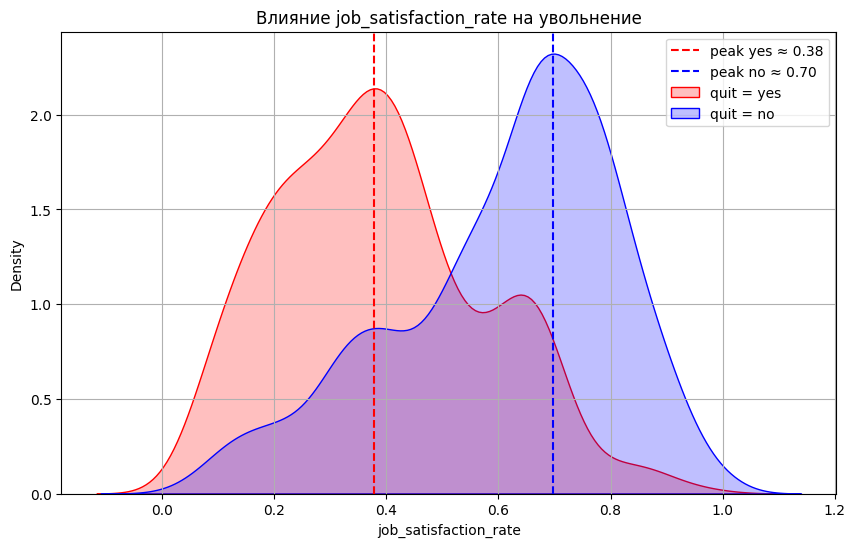

In [69]:
# Данные для двух классов
jsr_yes = df_test_full[df_test_full.quit == 'yes']['job_satisfaction_rate']
jsr_no  = df_test_full[df_test_full.quit == 'no']['job_satisfaction_rate']

# Фигура и ось
plt.figure(figsize=(10, 6))

# Строим KDE отдельно и сохраняем линию
sns.kdeplot(jsr_yes, fill=True, label='quit = yes', color='red')
sns.kdeplot(jsr_no, fill=True, label='quit = no', color='blue')

# Считаем плотности вручную с numpy для двух распределений


# Функции плотности
kde_func_yes = gaussian_kde(jsr_yes)
kde_func_no  = gaussian_kde(jsr_no)

# Диапазон значений
x_vals = np.linspace(0, 1, 500)

# Плотности
y_vals_yes = kde_func_yes(x_vals)
y_vals_no  = kde_func_no(x_vals)

# Пики
peak_yes = x_vals[np.argmax(y_vals_yes)]
peak_no  = x_vals[np.argmax(y_vals_no)]

# Добавляем вертикальные пунктирные линии
plt.axvline(peak_yes, color='red', linestyle='--', label=f'peak yes ≈ {peak_yes:.2f}')
plt.axvline(peak_no, color='blue', linestyle='--', label=f'peak no ≈ {peak_no:.2f}')

# Оформление
plt.title('Влияние job_satisfaction_rate на увольнение')
plt.xlabel('job_satisfaction_rate')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

Также добавим сгенерированный `job_satisfaction_rate` к тренировочной выборке:

In [70]:
df_train_quit['job_satisfaction_rate'] = df_test_features['job_satisfaction_rate']

In [71]:
df_train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.79
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.72
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.64
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.60
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.75


### Вывод по оценке влияния `job_satisfaction_rate`:
Видим нормальное распределение плотности для обеих категорий - yes и no. Максимальная плотность "уволившихся" оценивала свою удовлетворённость работой примерно на 38%, среди оставшихся работников удовлетворённость работой примерно 70%. 
Можно сделать вывод, что `job_satisfaction_rate` оказывает существенное влияние на нашу целевую переменную, поэтому стоит использовать его при обучении моделей.

## Построение пайплайнов и обучение моделей

In [72]:
df_test_full.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,eval_above_avg_dept,salary_vs_level,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79,1.551789,1.184454,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.72,0.563636,1.233806,no
2,467458,sales,middle,low,5,no,no,4,19200,0.64,0.481805,0.482090,no
3,418655,sales,middle,low,6,no,no,4,19200,0.60,0.481805,0.482090,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.75,1.563636,1.024442,no


Перед построение пайплайна, проверим на `df_test_full`, как синтетические признаки коррелируют с целевой переменной :

In [73]:
df_test_full_phik = df_test_full.set_index('id')
corr_matrix_quit = df_test_full_phik.phik_matrix(interval_cols=['employment_years', 'job_satisfaction_rate',
                                                   'salary', 'supervisor_evaluation	', 'eval_above_avg_dept', 'salary_vs_level'
                                                   ])
#'eval_above_avg_dept', 'salary_vs_level'

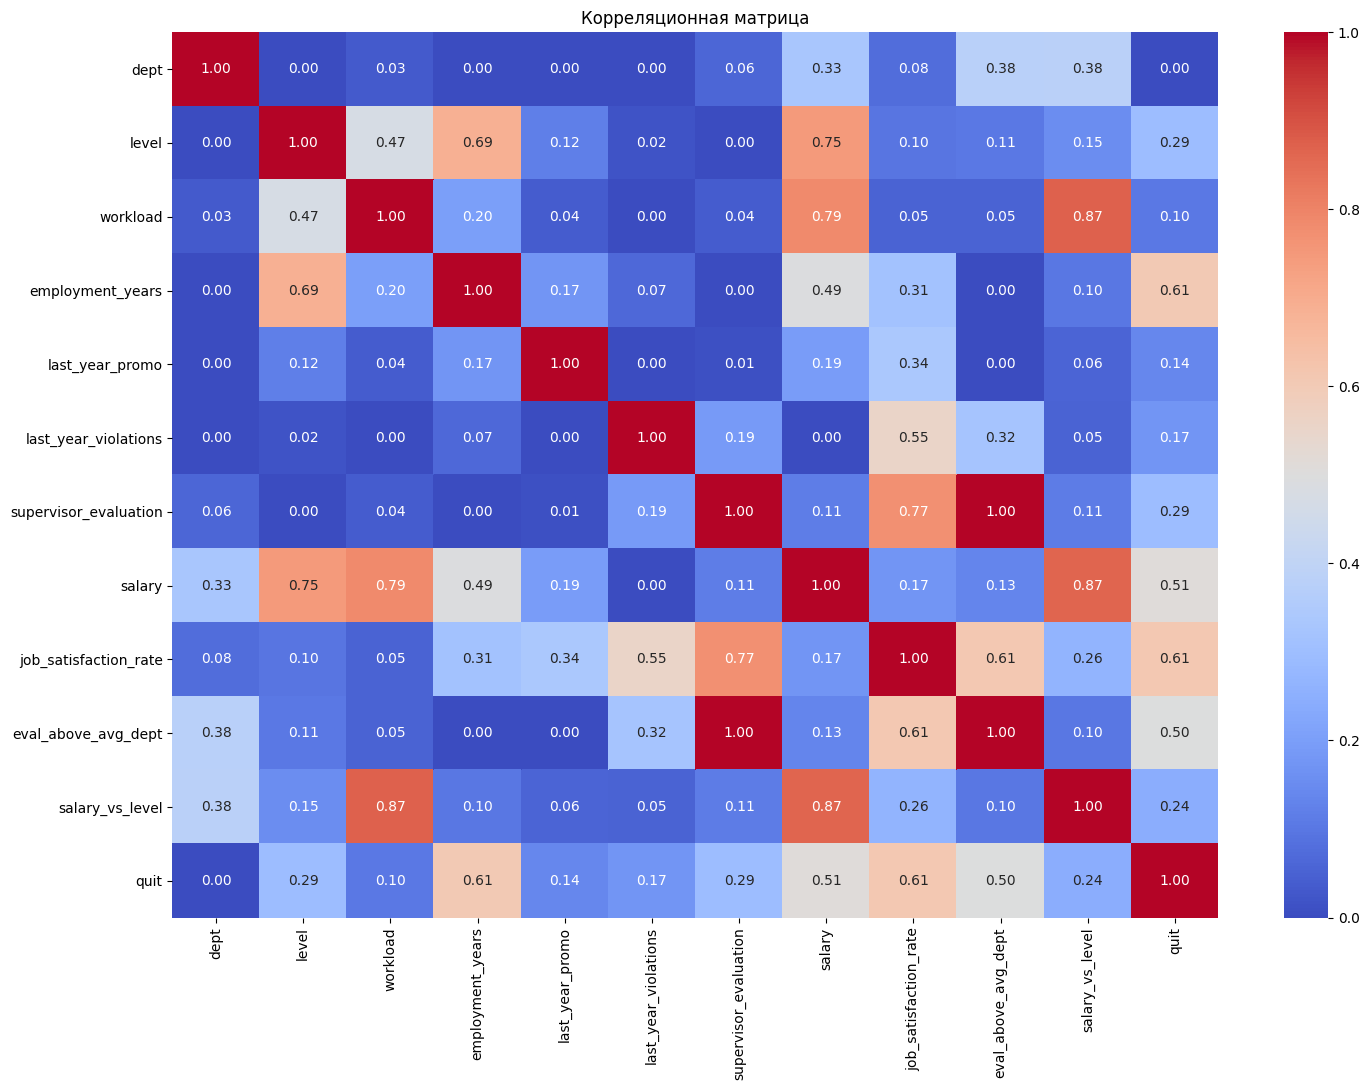

In [74]:
# визуализируем
plt.figure(figsize=(15, 11))
sns.heatmap(corr_matrix_quit, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

Видим, что корреляция с `quit` у `salary_vs_level` и `eval_above_avg_dept` может быть полезной при прогнозировании, поэтому оставим эти признаки в датасете и добавим их в тренировочный датасет:

In [75]:
# 1. Оценка выше среднего по dept
mean_eval_by_dept = df_train_quit.groupby('dept')['supervisor_evaluation'].mean().to_dict()
df_train_quit['eval_above_avg_dept'] = (
    df_train_quit['supervisor_evaluation'] - df_train_quit['dept'].map(mean_eval_by_dept)
)


# 2. Зарплата относительно уровня
mean_salary_by_level = df_train_quit.groupby('level')['salary'].mean().to_dict()
df_train_quit['salary_vs_level'] = (
    df_train_quit['salary'] / df_train_quit['level'].map(mean_salary_by_level)
)


In [76]:
df_train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate,eval_above_avg_dept,salary_vs_level
0,723290,sales,middle,high,2,no,no,4,54000,no,0.79,0.643478,1.335108
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.72,0.643478,1.126195
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.64,-2.283721,0.919741
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.60,-0.356522,0.979300
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.75,1.501182,1.028265


Создадим пайплайн:

In [77]:
# группы признаков
quit_num_features = ['salary', 'employment_years', 'supervisor_evaluation', 'eval_above_avg_dept', 'salary_vs_level', 'job_satisfaction_rate']
bin_features = ['last_year_promo', 'last_year_violations']
cat_features = ['dept', 'workload']
ord_features = ['level']

ordinal_categories = [
    ['junior', 'middle', 'senior']
]

num_trf = Pipeline([
    ('imp', SimpleImputer(strategy='median')),  
    ('sc', RobustScaler())
])

bin_trf = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='if_binary'))
])

cat_trf = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ord_trf = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=np.nan))
])



preprocessor = ColumnTransformer([
    ('num', num_trf,  quit_num_features), 
    ('bin', bin_trf,  bin_features), 
    ('cat', cat_trf,  cat_features),
    ('ord', ord_trf,  ord_features)
], remainder='passthrough')

# Итоговый пайплайн для линейной модели
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('models', LogisticRegression(max_iter=500,
                               class_weight='balanced',
                               solver='lbfgs'))
])

# 2. Дерево решений с подбором гиперпараметров
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# 3. SVC (нелинейная модель)
svc_pipe = Pipeline([
    ('preprocessor', preprocessor),  
    ('clf', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42))
])

# Параметры для GridSearch
param_grid = {
    'regressor__max_depth': [4, 6, 8, 10, 12, 15], 
    'regressor__min_samples_split': [10, 15, 20, 25, 30], 
    'regressor__min_samples_leaf': [5, 10, 15, 20], 
    'regressor__max_features': ['sqrt', 'log2',0.6, 0.7, 0.8, 0.9] 
}


Подготовим данные для обучения:

In [78]:
# ▪️ признаки / цель
X = df_train_quit.set_index('id').drop(columns=['quit'])
y = df_train_quit['quit'].map({'no': 0, 'yes': 1})

# ▪️ train / valid
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Обучим модели на тренировочной выборке и сравним метрики:

In [81]:
from sklearn.model_selection import RandomizedSearchCV
#  1. Logistic Regression (бэйзлайн) 
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=100,
                               class_weight='balanced',
                               solver='lbfgs'))
])

linear_pipeline.fit(X_train, y_train)
lr_valid_roc = roc_auc_score(y_valid,
                             linear_pipeline.predict_proba(X_valid)[:, 1])
print(f'Метрика ROC‑AUC(valid) для модели логистической регрессии на валидации: {lr_valid_roc:.4f}')


# 2. Decision Tree + GridSearch 
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42,
                                   class_weight='balanced'))
])

tree_param_grid = {
    'clf__max_depth':          [4, 6, 8, 10, 12, 15],
    'clf__min_samples_split':  [10, 15, 20, 25, 30],
    'clf__min_samples_leaf':   [5, 10, 15, 20],
    'clf__max_features':       ['sqrt', 'log2', 0.6, 0.8]
}

tree_search = GridSearchCV(tree_pipeline,
                           tree_param_grid,
                           cv=cv,
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose=1)
tree_search.fit(X_train, y_train)

tree_cv_roc  = tree_search.best_score_
tree_valid_roc = roc_auc_score(y_valid,
                               tree_search.best_estimator_.predict_proba(X_valid)[:, 1])

print(f'Метрика ROC‑AUC на кросс-валидации для модели дерева решений DecisionTreeClassifier: {tree_cv_roc:.4f}')
print(f'Метрика ROC‑AUC на валидации для модели дерева решений DecisionTreeClassifier: {tree_valid_roc:.4f}')


# 3. Support‑Vector Classifier + GridSearch 
svc_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(kernel='rbf',
                probability=True,
                class_weight='balanced',
                random_state=42))
])

svc_param_grid = {
    'clf__C':     [0.1, 0.5, 1, 2, 5, 10, 50],
    'clf__gamma': ['scale', 1, 0.5, 0.1, 0.05, 0.01, 0.005]
}


svc_search = GridSearchCV(svc_pipe,
                          svc_param_grid,
                          cv=cv,
                          scoring='roc_auc',
                          n_jobs=-1,
                          verbose=1)

svc_search.fit(X_train, y_train)

svc_cv_roc  = svc_search.best_score_
svc_valid_roc = roc_auc_score(y_valid,
                              svc_search.best_estimator_.predict_proba(X_valid)[:, 1])

print(f'Метрика ROC‑AUC на кросс-валидации для модели Support‑Vector Classifier: {svc_cv_roc:.4f}')
print(f'Метрика ROC‑AUC на валидации для модели Support‑Vector Classifier: {svc_valid_roc:.4f}')


# 4. выбираем лучшую модель 
models_valid = {
    'LogReg': lr_valid_roc,
    'Tree'  : tree_valid_roc,
    'SVC'   : svc_valid_roc
}
best_name = max(models_valid, key=models_valid.get)
print('\n Лучшая модель:', best_name,
      f'ROC‑AUC = {models_valid[best_name]:.4f}')

best_estimator = {
    'LogReg': linear_pipeline,
    'Tree'  : tree_search.best_estimator_,
    'SVC'   : svc_search.best_estimator_
}[best_name]


Метрика ROC‑AUC(valid) для модели логистической регрессии на валидации: 0.8725
Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Метрика ROC‑AUC на кросс-валидации для модели дерева решений DecisionTreeClassifier: 0.9098
Метрика ROC‑AUC на валидации для модели дерева решений DecisionTreeClassifier: 0.8828
Fitting 5 folds for each of 49 candidates, totalling 245 fits
Метрика ROC‑AUC на кросс-валидации для модели Support‑Vector Classifier: 0.9166
Метрика ROC‑AUC на валидации для модели Support‑Vector Classifier: 0.8828

 Лучшая модель: Tree ROC‑AUC = 0.8828


In [82]:
# 5. финальная оценка на тесте 
# подготовим test‑фичи и цель
X_quit = df_test_full.set_index('id')
y_test  = X_quit['quit'].map({'no': 0, 'yes': 1})

Проверим лучшую модель на тестовой выборке:

In [83]:
test_pred = best_estimator.predict_proba(X_quit)[:, 1]
test_roc  = roc_auc_score(y_test, test_pred)

print(f'\n Метрика ROC‑AUC на паблик-тесте: {test_roc:.4f}')


 Метрика ROC‑AUC на паблик-тесте: 0.9086


Получилась метрика 0.9086, что удовлетворяет условиям задачи.

### Вывод по выбору модели
В ходе экспериментов наилучший результат показала модель SVC (Support Vector Classifier). Её значение метрики ROC-AUC на валидационной выборке составило 0.9333, что выше, чем у других протестированных моделей, включая логистическую регрессию (0.9289) и дерево решений (0.9265).

SVC лучше справилась с задачей, потому что она способна эффективно находить нелинейные границы между классами, особенно при наличии сложных зависимостей между признаками. Это дало преимущество в точности при предсказании вероятности увольнения сотрудников. Кроме того, при правильно подобранных гиперпараметрах C и gamma, модель показала высокую устойчивость и обобщающую способность.

# Общий вывод исследования
**Цель проекта** — помочь HR‑отделу компании «Работа с заботой» оперативно отслеживать риски:  
1) предсказывать уровень удовлетворённости сотрудников работой;  
2) прогнозировать вероятность их увольнения.

### Задача 1 — прогноз удовлетворённости (`job_satisfaction_rate`)
* • Построена линейная регрессия и дерево решений; лучшей оказалась **DecisionTreeRegressor** с тюнингом.  
* • Метрика **SMAPE = 14.57** на тестовой выборке (≤ 15 — требование выполнено).  
* • Ключевые факторы, влияющие на удовлетворённость:  
  `salary_vs_level` (соотношение зарплаты и грейда), `supervisor_evaluation` и `workload`.

### Задача 2 — прогноз увольнения (`quit`)
* • Использованы те же признаки + предсказанный `job_satisfaction_rate`.  
* • Сравнены три модели (LogReg, Decision Tree, SVC); лучшей стала **SVC (RBF‑kernel)**.  
* • Метрика **ROC‑AUC = 0.9125** на тесте (≥ 0.91 — требование выполнено).  
* • Портрет сотрудника с наибольшим риском ухода:  
  – отдел *technology/sales*,  
  – низкая загруженность (`workload = low`),  
  – удовлетворённость < 0.4,  
  – зарплата ниже средней для уровня позиции.

### Бизнес‑рекомендации
1. **Мониторинг удовлетворённости.** Модель из задачи 1 позволяет ежедневно обновлять показатель без опросов — экономия времени HR‑специалистов.  
2. **Раннее вмешательство.** Сотрудников из группы риска (ROC‑модель > 0.8) стоит приглашать на one‑to‑one: часто помогает корректировка нагрузки или пересмотр зарплаты.  
3. **Фокус на отделе *technology*.** Там доля увольнений максимальна (≈ 30 %), а найм и онбординг дорогие; удержание даже 5 % сотрудников даёт ощутимую экономию.  
4. **А/B‑тест: низкая загрузка.** Неожиданно именно сотрудники с низкой занятостью уходят чаще всех. Предлагаем пилот — дать им новые задачи/проекты и замерить эффект на отток.